In [17]:
import os
import sys
import clr
import pandas as pd


# ==========================================================
# 1. CONFIGURACIÓN DE LA CONSULTA
# ==========================================================

# ----------------------------------------------------------
# TAGS DEL PROYECTO
# ----------------------------------------------------------

TAGS = [

    # ======================================================
    # BALANCE DE VAPOR
    # ======================================================

    # Vapor MS importado desde límite de batería
    "FCCFI30303BM.DACA.PV",

    # Vapor MS exportado desde FCC
    "FCCFI30303AM.DACA.PV",

    # Vapor MS generado dentro de FCC
    "FCCFI12901M.DACA.PV",

    # Consumo de vapor turbina del compresor de gases
    "RG1FI00303.DACA.PV",


    # ======================================================
    # CONDENSADOR / VACÍO
    # ======================================================

    # Vacío / presión absoluta del condensador
    "FCCPI13162M.PV",

    # Flujo de agua de mar al condensador
    "FCCFI30202.DACA.PV",

    # Temperatura entrada agua de mar
    "FCCTI30204.DACA.PV",

    # Temperatura salida agua de mar
    "FCCTI30208.DACA.PV",

    # Presión entrada agua de mar
    "FCCPI30204.DACA.PV",


    # ======================================================
    # SOPLADOR / TURBINA
    # ======================================================

    # Flujo de aire del soplador
    "FCCFI10561M.DACA.PV",

    # Temperatura descarga del soplador
    "FCCTI10464.PV",

    # Presión descarga del soplador
    "FCCPI10463.PV",

    # RPM turbina / soplador
    "FCCSI70129B.PV",

    # Presión vapor entrada turbina
    "FCCPI10405M.PV",

    # Temperatura vapor entrada turbina
    "FCCTI10401M.PV",

    # Apertura antisurge
    "FCCZI10461.PV",


    # ======================================================
    # REGENERADOR
    # ======================================================

    # Presión del regenerador
    "FCCPC11203.PIDA.PV",

    # Posición válvula SV3
    "FCCPDX12601B.DACA.PV",


    # ======================================================
    # EYECTORES
    # ======================================================

    # Presión vapor MS hacia eyectores
    "FCCPI30304.DACA.PV",

    # Temperatura vapor MS hacia eyectores
    "FCCTI30304.DACA.PV",
]


# ==========================================================
# 2. RANGO DE TIEMPO
# ==========================================================

# Primera prueba: últimos 7 días
#INICIO = "NOW-7D"
#FIN = "NOW"
INICIO = "2026-05-01 00:00:00"
FIN = "2026-08-18 23:59:00"

# ==========================================================
# 3. INTERVALO
# ==========================================================

# Promedio cada 1 minuto
INTERVALO_MIN = 1


# ==========================================================
# 4. TIPO DE MUESTREO
# ==========================================================

# "Average"  = promedio de los valores dentro del intervalo
# "Snapshot" = valor puntual

TIPO_MUESTREO = "Average"


# ==========================================================
# 5. CONSUMO NOMINAL BOMBA DE FONDOS
# ==========================================================

# kg/h
CONSUMO_BOMBA_FONDOS = 8396


# ==========================================================
# 6. CONFIGURACIÓN DE UNIFORMANCE PHD
# ==========================================================

RUTA = r"C:\Program Files\Honeywell\Uniformance\Excel Companion"

if RUTA not in sys.path:
    sys.path.append(RUTA)

if hasattr(os, "add_dll_directory"):
    dll_dir = os.add_dll_directory(RUTA)

clr.AddReference(
    os.path.join(
        RUTA,
        "phdapinet.dll"
    )
)


# ==========================================================
# 7. IMPORTAR CLASES DE UNIFORMANCE
# ==========================================================

from Uniformance.PHD import (
    PHDServer,
    PHDHistorian,
    Tag,
    SERVERVERSION,
    SAMPLETYPE,
    REDUCTIONTYPE,
    REDUCTIONOFFSET
)


# ==========================================================
# 8. CONECTAR AL SERVIDOR PHD
# ==========================================================

print("Conectando al PHD...")

server = PHDServer(
    "10.2.18.69",
    SERVERVERSION.RAPI200
)

server.ConnectToServer()

print("✅ Conectado al PHD")
print("Servidor:", server.HostName)
print("Puerto:", server.Port)
print("API:", server.APIVersion)


# ==========================================================
# 9. CONFIGURAR CONSULTA HISTÓRICA
# ==========================================================

historian = PHDHistorian()

historian.DefaultServer = server

historian.StartTime = INICIO
historian.EndTime = FIN


# Convertir minutos a segundos
historian.SampleFrequency = INTERVALO_MIN * 60

historian.UseSampleFrequency = True


# ==========================================================
# 10. DEFINIR TIPO DE MUESTREO
# ==========================================================

if TIPO_MUESTREO.lower() == "average":

    historian.Sampletype = SAMPLETYPE.Average

elif TIPO_MUESTREO.lower() == "snapshot":

    historian.Sampletype = SAMPLETYPE.Snapshot

else:

    raise ValueError(
        "TIPO_MUESTREO debe ser 'Average' o 'Snapshot'"
    )


print("\nCONFIGURACIÓN DE CONSULTA")
print("--------------------------")
print("Inicio:", INICIO)
print("Fin:", FIN)
print("Intervalo:", INTERVALO_MIN, "minuto(s)")
print("Tipo:", TIPO_MUESTREO)
print("Número de tags:", len(TAGS))


# ==========================================================
# 11. FUNCIÓN PARA CONSULTAR UN TAG
# ==========================================================

def obtener_tag(nombre_tag):

    print(f"\nConsultando: {nombre_tag}")

    # Crear objeto Tag
    tag = Tag()

    tag.TagName = nombre_tag
    tag.Server = server


    # Sin reducción adicional
    tag.ReductionType = getattr(
        REDUCTIONTYPE,
        "None"
    )

    tag.ReductionFrequency = 0

    tag.ReductionOffset = REDUCTIONOFFSET.Before


    # ======================================================
    # CONSULTAR PHD
    # ======================================================

    datos = historian.FetchDataList(tag)


    # ======================================================
    # CONVERTIR DATOS .NET A PYTHON
    # ======================================================

    timestamps = list(datos.Timestamps)
    valores = list(datos.DataValues)


    # ======================================================
    # CREAR DATAFRAME DEL TAG
    # NO INCLUIMOS CONFIDENCE
    # ======================================================

    df_tag = pd.DataFrame({

        "Timestamp_PHD": timestamps,

        nombre_tag: valores

    })


    # ======================================================
    # CONVERTIR TIMESTAMP PHD A FECHA/HORA
    # ======================================================

    df_tag["FechaHora"] = pd.to_datetime(

        df_tag["Timestamp_PHD"],

        unit="D",

        origin="1899-12-30"

    ).dt.round("min")


    # ======================================================
    # ELIMINAR TIMESTAMP NUMÉRICO
    # ======================================================

    df_tag = df_tag.drop(
        columns=["Timestamp_PHD"]
    )


    # ======================================================
    # SI EXISTE MÁS DE UN DATO EN EL MISMO MINUTO
    # SE QUEDA CON EL PROMEDIO
    # ======================================================

    df_tag = (
        df_tag
        .groupby(
            "FechaHora",
            as_index=False
        )[nombre_tag]
        .mean()
    )


    print(
        f"✅ {len(df_tag)} datos obtenidos"
    )


    return df_tag


# ==========================================================
# 12. CONSULTAR TODOS LOS TAGS
# ==========================================================

dataframes = []


for nombre_tag in TAGS:

    try:

        df_tag = obtener_tag(nombre_tag)

        dataframes.append(df_tag)

    except Exception as e:

        print(
            f"\n❌ Error consultando {nombre_tag}"
        )

        print(e)


# ==========================================================
# 13. VERIFICAR QUE HAYA DATOS
# ==========================================================

if len(dataframes) == 0:

    raise RuntimeError(
        "No se pudo obtener información de ningún tag."
    )


# ==========================================================
# 14. UNIR TODOS LOS TAGS POR FECHA/HORA
# ==========================================================

df = dataframes[0]


for df_tag in dataframes[1:]:

    df = pd.merge(

        df,

        df_tag,

        on="FechaHora",

        how="outer"

    )


# ==========================================================
# 15. ORDENAR RESULTADOS
# ==========================================================

df = df.sort_values(
    "FechaHora"
).reset_index(drop=True)


# ==========================================================
# 16. CAMBIAR NOMBRES DE COLUMNAS
# ==========================================================

df = df.rename(columns={

    # Balance de vapor
    "FCCFI30303BM.DACA.PV":
        "Vapor_MS_Importado_kg_h",

    "FCCFI30303AM.DACA.PV":
        "Vapor_MS_Exportado_kg_h",

    "FCCFI12901M.DACA.PV":
        "Vapor_MS_Generado_kg_h",

    "RG1FI00303.DACA.PV":
        "Vapor_Compresor_Gases_kg_h",


    # Condensador
    "FCCPI13162M.PV":
        "Presion_Condensador_kg_cm2A",

    "FCCFI30202.DACA.PV":
        "Flujo_Agua_Mar_m3_h",

    "FCCTI30204.DACA.PV":
        "Temp_Entrada_Agua_Mar_C",

    "FCCTI30208.DACA.PV":
        "Temp_Salida_Agua_Mar_C",

    "FCCPI30204.DACA.PV":
        "Presion_Entrada_Agua_Mar_kg_cm2",


    # Soplador / turbina
    "FCCFI10561M.DACA.PV":
        "Flujo_Aire_Soplador_kg_h",

    "FCCTI10464.PV":
        "Temp_Descarga_Soplador_C",

    "FCCPI10463.PV":
        "Presion_Descarga_Soplador_kg_cm2",

    "FCCSI70129B.PV":
        "RPM_Turbina",

    "FCCPI10405M.PV":
        "Presion_Vapor_Entrada_Turbina_kg_cm2",

    "FCCTI10401M.PV":
        "Temp_Vapor_Entrada_Turbina_C",

    "FCCZI10461.PV":
        "Apertura_Antisurge_pct",


    # Regenerador
    "FCCPC11203.PIDA.PV":
        "Presion_Regenerador_kg_cm2",

    "FCCPDX12601B.DACA.PV":
        "Apertura_SV3_pct",


    # Eyectores
    "FCCPI30304.DACA.PV":
        "Presion_MS_Eyectores_kg_cm2",

    "FCCTI30304.DACA.PV":
        "Temp_MS_Eyectores_C"

})


# ==========================================================
# 17. CALCULAR CONSUMO DE VAPOR DE LA TURBINA DEL SOPLADOR
# ==========================================================
#
# Balance:
#
# Vapor soplador =
#
#   Vapor importado
# - Vapor exportado
# + Vapor generado
# - Vapor consumido compresor de gases
# - Vapor bomba de fondos
#
# Bomba de fondos:
# 8396 kg/h
#
# ==========================================================

df["Flujo_Vapor_Turbina_kg_h"] = (

    df["Vapor_MS_Importado_kg_h"]

    - df["Vapor_MS_Exportado_kg_h"]

    + df["Vapor_MS_Generado_kg_h"]

    - df["Vapor_Compresor_Gases_kg_h"]

    - CONSUMO_BOMBA_FONDOS

)


# ==========================================================
# 18. CONVERTIR CONSUMO A TONELADAS/HORA
# ==========================================================

df["Flujo_Vapor_Turbina_t_h"] = (

    df["Flujo_Vapor_Turbina_kg_h"] / 1000

)


# ==========================================================
# 19. CREAR VARIABLE ΔT AGUA DE MAR
# ==========================================================

df["DeltaT_Agua_Mar_C"] = (

    df["Temp_Salida_Agua_Mar_C"]

    - df["Temp_Entrada_Agua_Mar_C"]

)


# ==========================================================
# 20. CREAR ESTADO DE OPERACIÓN PRELIMINAR
# ==========================================================
#
# Esto NO elimina datos.
# Solo identifica cuándo la turbina/soplador está detenido.
#
# Después afinaremos este criterio en Databricks.
#
# ==========================================================

df["Estado_Operacion"] = "FUERA_DE_SERVICIO"

df.loc[
    (df["RPM_Turbina"] >= 5000) &
    (df["Flujo_Aire_Soplador_kg_h"] > 10000),
    "Estado_Operacion"
] = "EN_SERVICIO"


# ==========================================================
# 21. ORDENAR COLUMNAS
# ==========================================================

columnas_finales = [

    "FechaHora",

    # VARIABLE OBJETIVO
    "Flujo_Vapor_Turbina_t_h",
    "Flujo_Vapor_Turbina_kg_h",

    # VARIABLE PRINCIPAL
    "Presion_Condensador_kg_cm2A",

    # CARGA SOPLADOR
    "Flujo_Aire_Soplador_kg_h",
    "Temp_Descarga_Soplador_C",
    "Presion_Descarga_Soplador_kg_cm2",
    "RPM_Turbina",

    # VAPOR TURBINA
    "Presion_Vapor_Entrada_Turbina_kg_cm2",
    "Temp_Vapor_Entrada_Turbina_C",

    # CONDENSADOR / AGUA DE MAR
    "Flujo_Agua_Mar_m3_h",
    "Temp_Entrada_Agua_Mar_C",
    "Temp_Salida_Agua_Mar_C",
    "DeltaT_Agua_Mar_C",
    "Presion_Entrada_Agua_Mar_kg_cm2",

    # REGENERADOR
    "Presion_Regenerador_kg_cm2",
    "Apertura_SV3_pct",

    # ANTISURGE
    "Apertura_Antisurge_pct",

    # EYECTORES
    "Presion_MS_Eyectores_kg_cm2",
    "Temp_MS_Eyectores_C",

    # BALANCE DE VAPOR ORIGINAL
    "Vapor_MS_Importado_kg_h",
    "Vapor_MS_Exportado_kg_h",
    "Vapor_MS_Generado_kg_h",
    "Vapor_Compresor_Gases_kg_h",

    # ESTADO
    "Estado_Operacion"
]


df = df[columnas_finales]


# ==========================================================
# 22. MOSTRAR RESULTADO FINAL
# ==========================================================

print("\n")
print("=" * 80)
print("✅ CONSULTA PHD TERMINADA")
print("=" * 80)

print("\nCantidad de registros:", len(df))

print("\nNúmero de variables:", len(df.columns))

print("\nPrimeros registros:\n")

print(
    df.head(20).to_string(
        index=False
    )
)


# ==========================================================
# 23. MOSTRAR RESUMEN DEL CONSUMO CALCULADO
# ==========================================================

print("\n")
print("=" * 80)
print("CONSUMO CALCULADO DE VAPOR - TURBINA SOPLADOR")
print("=" * 80)

print(
    df["Flujo_Vapor_Turbina_t_h"].describe()
)


# ==========================================================
# 24. DATAFRAME FINAL
# ==========================================================

df

Conectando al PHD...
✅ Conectado al PHD
Servidor: 10.2.18.69
Puerto: 3150
API: RAPI200

CONFIGURACIÓN DE CONSULTA
--------------------------
Inicio: 2026-05-01 00:00:00
Fin: 2026-08-18 23:59:00
Intervalo: 1 minuto(s)
Tipo: Average
Número de tags: 20

Consultando: FCCFI30303BM.DACA.PV
✅ 158400 datos obtenidos

Consultando: FCCFI30303AM.DACA.PV
✅ 158400 datos obtenidos

Consultando: FCCFI12901M.DACA.PV
✅ 158400 datos obtenidos

Consultando: RG1FI00303.DACA.PV
✅ 158400 datos obtenidos

Consultando: FCCPI13162M.PV
✅ 158400 datos obtenidos

Consultando: FCCFI30202.DACA.PV
✅ 158400 datos obtenidos

Consultando: FCCTI30204.DACA.PV
✅ 158400 datos obtenidos

Consultando: FCCTI30208.DACA.PV
✅ 158400 datos obtenidos

Consultando: FCCPI30204.DACA.PV
✅ 158400 datos obtenidos

Consultando: FCCFI10561M.DACA.PV
✅ 158400 datos obtenidos

Consultando: FCCTI10464.PV
✅ 158400 datos obtenidos

Consultando: FCCPI10463.PV
✅ 158400 datos obtenidos

Consultando: FCCSI70129B.PV
✅ 158400 datos obtenidos

Consult

,FechaHora,Flujo_Vapor_Turbina_t_h,Flujo_Vapor_Turbina_kg_h,Presion_Condensador_kg_cm2A,Flujo_Aire_Soplador_kg_h,Temp_Descarga_Soplador_C,Presion_Descarga_Soplador_kg_cm2,RPM_Turbina,Presion_Vapor_Entrada_Turbina_kg_cm2,Temp_Vapor_Entrada_Turbina_C,...,Presion_Regenerador_kg_cm2,Apertura_SV3_pct,Apertura_Antisurge_pct,Presion_MS_Eyectores_kg_cm2,Temp_MS_Eyectores_C,Vapor_MS_Importado_kg_h,Vapor_MS_Exportado_kg_h,Vapor_MS_Generado_kg_h,Vapor_Compresor_Gases_kg_h,Estado_Operacion
0,2026-05-01 00:00:00,33.880236,33880.236328,0.050061,124478.617188,164.764969,2.306471,5324.481445,40.961540,343.826324,...,1.860262,33.818588,33.690475,10.859919,259.716370,27983.869141,0.0,25265.792969,10973.425781,EN_SERVICIO
1,2026-05-01 00:01:00,33.909539,33909.539062,0.050061,124495.304688,164.722229,2.311355,5327.228516,41.034798,344.341431,...,1.859373,33.853645,33.693527,10.850438,259.711914,28253.207031,0.0,25024.755859,10972.423828,EN_SERVICIO
2,2026-05-01 00:02:00,33.890573,33890.573242,0.050061,124501.570312,164.775650,2.310440,5324.786621,41.028694,344.207886,...,1.860790,33.451866,33.678265,10.849522,259.734131,26953.349609,0.0,26328.285156,10995.061523,EN_SERVICIO
3,2026-05-01 00:03:00,33.864421,33864.420898,0.050061,124296.460938,164.786331,2.310440,5327.839355,41.028694,344.150665,...,1.863403,33.752090,33.659950,10.841509,259.713043,27364.400391,0.0,25875.843750,10979.823242,EN_SERVICIO
4,2026-05-01 00:04:00,33.979686,33979.685547,0.050137,124659.398438,164.797012,2.311661,5327.839355,41.047009,344.074341,...,1.865417,34.112686,33.565327,10.832578,259.678558,27786.103516,0.0,25561.562500,10971.980469,EN_SERVICIO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158395,2026-08-18 23:55:00,33.676523,33676.523438,0.084249,97973.296875,168.557693,2.432235,5324.481445,40.268620,341.517883,...,2.129689,12.346967,42.689255,11.241217,262.886902,31711.203125,0.0,21114.789062,10753.468750,EN_SERVICIO
158396,2026-08-18 23:56:00,33.668102,33668.101562,0.084249,97982.343750,168.547012,2.429487,5329.060059,40.225883,341.327087,...,2.127160,12.924597,42.725883,11.212591,262.879120,31767.919922,0.0,21035.414062,10739.232422,EN_SERVICIO
158397,2026-08-18 23:57:00,33.522654,33522.654297,0.084325,98033.789062,168.557693,2.426435,5324.481445,40.216728,341.422485,...,2.125146,12.390930,42.710625,11.213753,262.901367,31749.892578,0.0,20897.259766,10728.498047,EN_SERVICIO
158398,2026-08-18 23:58:00,33.394415,33394.415039,0.084783,97990.687500,168.611115,2.430403,5323.565430,40.195362,341.517883,...,2.126271,12.957150,42.689255,11.197851,262.933594,31761.769531,0.0,20771.935547,10743.290039,EN_SERVICIO


In [18]:
df_original = df.copy()

In [19]:
df.shape

(158400, 25)

In [20]:
df.describe()

,FechaHora,Flujo_Vapor_Turbina_t_h,Flujo_Vapor_Turbina_kg_h,Presion_Condensador_kg_cm2A,Flujo_Aire_Soplador_kg_h,Temp_Descarga_Soplador_C,Presion_Descarga_Soplador_kg_cm2,RPM_Turbina,Presion_Vapor_Entrada_Turbina_kg_cm2,Temp_Vapor_Entrada_Turbina_C,...,Presion_Entrada_Agua_Mar_kg_cm2,Presion_Regenerador_kg_cm2,Apertura_SV3_pct,Apertura_Antisurge_pct,Presion_MS_Eyectores_kg_cm2,Temp_MS_Eyectores_C,Vapor_MS_Importado_kg_h,Vapor_MS_Exportado_kg_h,Vapor_MS_Generado_kg_h,Vapor_Compresor_Gases_kg_h
count,158400,158400.000000,158400.000000,158400.000000,158400.000000,158400.000000,158400.000000,158400.000000,158400.000000,158400.000000,...,158400.000000,158400.000000,158400.000000,158400.000000,158400.000000,158400.000000,158400.000000,158400.000000,158400.000000,158400.000000
mean,2026-06-24 23:59:29.999999232,25.284900,25284.900091,0.265246,92741.641918,139.281301,1.826952,4276.387850,36.639899,305.742716,...,5.943619,1.511395,25.696055,48.287135,10.483830,242.962183,23456.425991,0.060272,18586.456425,8361.922052
min,2026-05-01 00:00:00,-11.190318,-11190.317627,0.000000,1206.133423,22.841881,0.002442,0.000000,0.000000,23.389805,...,0.155036,0.014054,0.000000,0.000000,0.000906,28.613213,0.000000,0.000000,0.000000,0.000000
25%,2026-05-28 11:59:45,30.102478,30102.478472,0.074405,91958.466797,159.687511,2.094628,5322.955078,40.094627,332.989960,...,6.020612,1.717143,15.109139,33.504272,10.866019,245.070297,23393.891602,0.000000,1783.113647,9654.511475
50%,2026-06-24 23:59:30,32.670793,32670.793457,0.098748,109334.109375,166.250000,2.298229,5324.481445,40.778389,339.056793,...,6.205580,1.868683,21.888981,38.974361,11.106777,253.225159,27059.178711,0.000000,23662.200195,10567.491211
75%,2026-07-22 11:59:15,34.099189,34099.189453,0.196352,123456.570312,168.621796,2.358974,5327.839355,41.266788,342.490845,...,6.648436,1.939863,34.302239,44.216270,11.359952,261.432312,29626.388672,0.000000,26444.614258,10762.201172
max,2026-08-18 23:59:00,57.131422,57131.421875,1.571505,175274.125000,185.224365,3.063797,5341.270020,43.049454,367.025360,...,8.563954,2.804236,99.956871,99.706963,12.489702,289.874817,60354.546875,26.509850,37047.757812,18766.898438
std,NaN,16.128252,16128.251915,0.349413,45386.469918,54.547996,0.925748,2116.985508,12.296139,84.082997,...,1.444194,0.748907,17.855046,26.277380,2.593424,47.307659,11900.728327,0.851232,11096.525328,4247.406085


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 158400 entries, 0 to 158399
Data columns (total 25 columns):
 #   Column                                Non-Null Count   Dtype         
---  ------                                --------------   -----         
 0   FechaHora                             158400 non-null  datetime64[ns]
 1   Flujo_Vapor_Turbina_t_h               158400 non-null  float64       
 2   Flujo_Vapor_Turbina_kg_h              158400 non-null  float64       
 3   Presion_Condensador_kg_cm2A           158400 non-null  float64       
 4   Flujo_Aire_Soplador_kg_h              158400 non-null  float64       
 5   Temp_Descarga_Soplador_C              158400 non-null  float64       
 6   Presion_Descarga_Soplador_kg_cm2      158400 non-null  float64       
 7   RPM_Turbina                           158400 non-null  float64       
 8   Presion_Vapor_Entrada_Turbina_kg_cm2  158400 non-null  float64       
 9   Temp_Vapor_Entrada_Turbina_C          158400 non-null  float64       


In [22]:
print(df["Estado_Operacion"].value_counts())

Estado_Operacion
EN_SERVICIO          127106
FUERA_DE_SERVICIO     31294
Name: count, dtype: int64


In [23]:
# Guardar una copia de todos los datos originales
df_original = df.copy()

# Seleccionar solamente los períodos con la unidad en servicio
df_operacion = df[
    df["Estado_Operacion"] == "EN_SERVICIO"
].copy()

# Ordenar cronológicamente
df_operacion = df_operacion.sort_values(
    "FechaHora"
).reset_index(drop=True)

print("Registros totales:", len(df_original))
print("Registros en servicio:", len(df_operacion))
print("Registros eliminados:", len(df_original) - len(df_operacion))

Registros totales: 158400
Registros en servicio: 127106
Registros eliminados: 31294


In [24]:
variables_revision = [
    "RPM_Turbina",
    "Presion_Condensador_kg_cm2A",
    "Flujo_Agua_Mar_m3_h",
    "Temp_Entrada_Agua_Mar_C",
    "Temp_Salida_Agua_Mar_C",
    "Presion_Entrada_Agua_Mar_kg_cm2",
    "Presion_MS_Eyectores_kg_cm2",
    "Temp_MS_Eyectores_C",
    "Flujo_Aire_Soplador_kg_h",
    "Presion_Descarga_Soplador_kg_cm2"
]

resumen_operacion = (
    df_operacion[variables_revision]
    .describe()
    .T
)

resumen_operacion

,count,mean,std,min,25%,50%,75%,max
RPM_Turbina,127106.0,5326.113832,3.183425,5036.630371,5324.175781,5325.396973,5328.144531,5341.270020
Presion_Condensador_kg_cm2A,127106.0,0.101521,0.048928,0.015263,0.067537,0.088294,0.111340,0.926358
Flujo_Agua_Mar_m3_h,127106.0,3372.146997,723.654606,843.583679,2989.216309,3297.275146,3487.821289,5000.000000
Temp_Entrada_Agua_Mar_C,127106.0,22.141889,1.377424,19.143658,21.223154,21.904821,22.724049,25.770231
Temp_Salida_Agua_Mar_C,127106.0,29.356760,2.105461,23.653362,28.039185,29.238653,31.218585,47.594734
Presion_Entrada_Agua_Mar_kg_cm2,127106.0,6.306448,0.339155,4.089936,6.106506,6.219772,6.627508,7.533339
Presion_MS_Eyectores_kg_cm2,127106.0,11.103418,0.290114,9.631863,10.893804,11.100966,11.363361,12.489702
Temp_MS_Eyectores_C,127106.0,253.796249,9.350405,226.253937,246.549362,253.676666,260.266548,289.874817
Flujo_Aire_Soplador_kg_h,127106.0,114320.204706,14395.174101,25314.837891,104472.046875,114529.910156,126421.048828,175274.125000
Presion_Descarga_Soplador_kg_cm2,127106.0,2.275753,0.219594,0.661172,2.271062,2.321734,2.371184,3.063797


In [27]:
eventos_vacio = df_operacion.loc[
    df_operacion["Presion_Condensador_kg_cm2A"] > 0.50,
    [
        "FechaHora",
        "RPM_Turbina",
        "Presion_Condensador_kg_cm2A",
        "Flujo_Agua_Mar_m3_h",
        "Temp_Entrada_Agua_Mar_C",
        "Temp_Salida_Agua_Mar_C",
        "Presion_Entrada_Agua_Mar_kg_cm2",
        "Presion_MS_Eyectores_kg_cm2",
        "Temp_MS_Eyectores_C",
        "Flujo_Aire_Soplador_kg_h",
        "Presion_Descarga_Soplador_kg_cm2"
    ]
]

print("Cantidad de registros con presión > 0.50 kg/cm²A:")
print(len(eventos_vacio))

eventos_vacio

Cantidad de registros con presión > 0.50 kg/cm²A:
11


,FechaHora,RPM_Turbina,Presion_Condensador_kg_cm2A,Flujo_Agua_Mar_m3_h,Temp_Entrada_Agua_Mar_C,Temp_Salida_Agua_Mar_C,Presion_Entrada_Agua_Mar_kg_cm2,Presion_MS_Eyectores_kg_cm2,Temp_MS_Eyectores_C,Flujo_Aire_Soplador_kg_h,Presion_Descarga_Soplador_kg_cm2
3762,2026-05-03 14:42:00,5323.565430,0.504426,1213.106689,20.015614,36.789253,7.293607,10.849215,256.233337,113078.875000,2.433150
3763,2026-05-03 14:43:00,5329.060059,0.640415,1208.921021,20.018955,38.441063,7.302328,10.817837,256.223328,111330.945312,2.418498
3764,2026-05-03 14:44:00,5324.481445,0.773504,1197.128662,20.021175,40.912979,7.314165,10.816063,256.244446,110555.710938,2.410867
3765,2026-05-03 14:45:00,5324.175781,0.883165,1193.568726,20.024073,42.931454,7.298979,10.738629,256.258911,110561.968750,2.407204
3766,2026-05-03 14:46:00,5327.228516,0.894002,1188.812866,20.024519,44.261314,7.301705,10.691717,256.252258,110445.859375,2.400794
3767,2026-05-03 14:47:00,5324.175781,0.921627,1188.228882,20.025187,45.788971,7.299019,10.671532,256.282257,110368.687500,2.394689
3768,2026-05-03 14:48:00,5324.481445,0.926358,1187.297119,20.029413,46.637119,7.278538,10.661379,256.324524,110389.546875,2.366300
3769,2026-05-03 14:49:00,5329.060059,0.895604,1187.714355,20.031635,47.124382,7.269349,10.680707,256.363464,110046.085938,2.244505
3770,2026-05-03 14:50:00,5325.091797,0.882479,1198.658325,20.033417,47.532661,7.234033,10.775084,256.423523,108993.429688,2.183150
3771,2026-05-03 14:51:00,5328.144531,0.880800,1213.648926,20.035198,47.594734,7.238823,10.965059,256.544708,108706.976562,2.205739


In [28]:
inicio_evento = "2026-05-03 14:10:00"
fin_evento = "2026-05-03 15:20:00"

evento_mayo = df_original.loc[
    (df_original["FechaHora"] >= inicio_evento) &
    (df_original["FechaHora"] <= fin_evento),
    [
        "FechaHora",
        "Estado_Operacion",
        "RPM_Turbina",
        "Presion_Condensador_kg_cm2A",
        "Flujo_Agua_Mar_m3_h",
        "Temp_Entrada_Agua_Mar_C",
        "Temp_Salida_Agua_Mar_C",
        "Presion_Entrada_Agua_Mar_kg_cm2",
        "Flujo_Aire_Soplador_kg_h",
        "Presion_Descarga_Soplador_kg_cm2"
    ]
]

evento_mayo

,FechaHora,Estado_Operacion,RPM_Turbina,Presion_Condensador_kg_cm2A,Flujo_Agua_Mar_m3_h,Temp_Entrada_Agua_Mar_C,Temp_Salida_Agua_Mar_C,Presion_Entrada_Agua_Mar_kg_cm2,Flujo_Aire_Soplador_kg_h,Presion_Descarga_Soplador_kg_cm2
3730,2026-05-03 14:10:00,EN_SERVICIO,5324.175781,0.045788,4244.937500,19.868103,25.358335,6.276737,117623.203125,2.471307
3731,2026-05-03 14:11:00,EN_SERVICIO,5328.449707,0.045788,4253.545410,19.862539,25.352329,6.278917,117551.585938,2.474970
3732,2026-05-03 14:12:00,EN_SERVICIO,5331.807129,0.045788,4252.808594,19.864321,25.367243,6.286938,117429.914062,2.475580
3733,2026-05-03 14:13:00,EN_SERVICIO,5326.312500,0.045788,4253.392578,19.859201,25.357452,6.296711,117488.320312,2.484127
3734,2026-05-03 14:14:00,EN_SERVICIO,5322.039062,0.045788,4257.174805,19.861427,25.344992,6.293713,117608.593750,2.483822
...,...,...,...,...,...,...,...,...,...,...
3796,2026-05-03 15:16:00,FUERA_DE_SERVICIO,0.000000,0.000000,3857.114746,20.095491,21.163189,6.747910,1516.915771,0.002442
3797,2026-05-03 15:17:00,FUERA_DE_SERVICIO,0.000000,0.000000,3950.020508,20.102167,21.127373,6.585038,1527.344727,0.002442
3798,2026-05-03 15:18:00,FUERA_DE_SERVICIO,0.000000,0.000000,4079.276123,20.097496,21.108013,6.511837,1524.567627,0.002442
3799,2026-05-03 15:19:00,FUERA_DE_SERVICIO,0.000000,0.000000,4113.749023,20.068796,21.087763,6.483101,1531.524536,0.002442


In [29]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=3,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    subplot_titles=[
        "Presión absoluta del condensador",
        "Flujo de agua de mar",
        "Temperatura de salida del agua de mar"
    ]
)

fig.add_trace(
    go.Scatter(
        x=evento_mayo["FechaHora"],
        y=evento_mayo["Presion_Condensador_kg_cm2A"],
        name="Presión condensador"
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=evento_mayo["FechaHora"],
        y=evento_mayo["Flujo_Agua_Mar_m3_h"],
        name="Flujo agua mar"
    ),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(
        x=evento_mayo["FechaHora"],
        y=evento_mayo["Temp_Salida_Agua_Mar_C"],
        name="T salida agua"
    ),
    row=3, col=1
)

fig.update_yaxes(title_text="kg/cm²A", row=1, col=1)
fig.update_yaxes(title_text="m³/h", row=2, col=1)
fig.update_yaxes(title_text="°C", row=3, col=1)

fig.update_xaxes(
    title_text="Fecha y hora",
    row=3,
    col=1
)

fig.update_layout(
    height=850,
    title="Evento de pérdida de vacío - 03/05/2026"
)

fig.show()

In [30]:
variables_modelo_vacio = [
    "Flujo_Agua_Mar_m3_h",
    "Temp_Entrada_Agua_Mar_C",
    "Temp_Salida_Agua_Mar_C",
    "Presion_Entrada_Agua_Mar_kg_cm2",
    "Presion_MS_Eyectores_kg_cm2",
    "Temp_MS_Eyectores_C",
    "Flujo_Aire_Soplador_kg_h",
    "Presion_Descarga_Soplador_kg_cm2"
]

objetivo_vacio = "Presion_Condensador_kg_cm2A"

df_modelo_vacio = df_operacion[
    ["FechaHora"] + variables_modelo_vacio + [objetivo_vacio]
].copy()

print("Registros para el modelo:", len(df_modelo_vacio))

df_modelo_vacio.head()

Registros para el modelo: 127106


,FechaHora,Flujo_Agua_Mar_m3_h,Temp_Entrada_Agua_Mar_C,Temp_Salida_Agua_Mar_C,Presion_Entrada_Agua_Mar_kg_cm2,Presion_MS_Eyectores_kg_cm2,Temp_MS_Eyectores_C,Flujo_Aire_Soplador_kg_h,Presion_Descarga_Soplador_kg_cm2,Presion_Condensador_kg_cm2A
0,2026-05-01 00:00:00,4117.475586,21.002157,26.648363,6.053902,10.859919,259.716370,124478.617188,2.306471,0.050061
1,2026-05-01 00:01:00,4115.445801,20.993258,26.613876,6.055304,10.850438,259.711914,124495.304688,2.311355,0.050061
2,2026-05-01 00:02:00,4119.408203,20.988808,26.626116,6.058653,10.849522,259.734131,124501.570312,2.310440,0.050061
3,2026-05-01 00:03:00,4122.690918,20.992592,26.620552,6.047906,10.841509,259.713043,124296.460938,2.310440,0.050061
4,2026-05-01 00:04:00,4119.700684,20.997047,26.601419,6.028671,10.832578,259.678558,124659.398438,2.311661,0.050137


In [31]:
# Asegurar orden cronológico
df_modelo_vacio = df_modelo_vacio.sort_values(
    "FechaHora"
).reset_index(drop=True)

# Punto de división: 80 % entrenamiento / 20 % prueba
corte = int(len(df_modelo_vacio) * 0.80)

train_vacio = df_modelo_vacio.iloc[:corte].copy()
test_vacio = df_modelo_vacio.iloc[corte:].copy()

print("Entrenamiento:", len(train_vacio))
print("Prueba:", len(test_vacio))

print("\nPeriodo de entrenamiento:")
print(train_vacio["FechaHora"].min(), "hasta", train_vacio["FechaHora"].max())

print("\nPeriodo de prueba:")
print(test_vacio["FechaHora"].min(), "hasta", test_vacio["FechaHora"].max())

Entrenamiento: 101684
Prueba: 25422

Periodo de entrenamiento:
2026-05-01 00:00:00 hasta 2026-07-20 17:42:00

Periodo de prueba:
2026-07-20 17:43:00 hasta 2026-08-18 23:59:00


In [32]:
variables_X = [
    "Flujo_Agua_Mar_m3_h",
    "Temp_Entrada_Agua_Mar_C",
    "Temp_Salida_Agua_Mar_C",
    "Presion_Entrada_Agua_Mar_kg_cm2",
    "Presion_MS_Eyectores_kg_cm2",
    "Temp_MS_Eyectores_C",
    "Flujo_Aire_Soplador_kg_h",
    "Presion_Descarga_Soplador_kg_cm2"
]

objetivo_y = "Presion_Condensador_kg_cm2A"

In [33]:
# Ordenar por fecha
df_modelo_vacio = df_modelo_vacio.sort_values(
    "FechaHora"
).reset_index(drop=True)

# División 80 % / 20 %
corte = int(len(df_modelo_vacio) * 0.80)

train_vacio = df_modelo_vacio.iloc[:corte].copy()
test_vacio = df_modelo_vacio.iloc[corte:].copy()

# Variables X e y
X_train = train_vacio[variables_X]
y_train = train_vacio[objetivo_y]

X_test = test_vacio[variables_X]
y_test = test_vacio[objetivo_y]

print("Entrenamiento:", len(X_train))
print("Prueba:", len(X_test))

print("\nPeriodo entrenamiento:")
print(
    train_vacio["FechaHora"].min(),
    "hasta",
    train_vacio["FechaHora"].max()
)

print("\nPeriodo prueba:")
print(
    test_vacio["FechaHora"].min(),
    "hasta",
    test_vacio["FechaHora"].max()
)

Entrenamiento: 101684
Prueba: 25422

Periodo entrenamiento:
2026-05-01 00:00:00 hasta 2026-07-20 17:42:00

Periodo prueba:
2026-07-20 17:43:00 hasta 2026-08-18 23:59:00


In [34]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

modelo_rf_vacio = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

modelo_rf_vacio.fit(X_train, y_train)

# Predicción
y_pred = modelo_rf_vacio.predict(X_test)

# Métricas
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RANDOM FOREST - DIVISIÓN TEMPORAL")
print("--------------------------------")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

RANDOM FOREST - DIVISIÓN TEMPORAL
--------------------------------
MAE: 0.01496068149604954
RMSE: 0.020206560481899106
R²: 0.8751333628238663


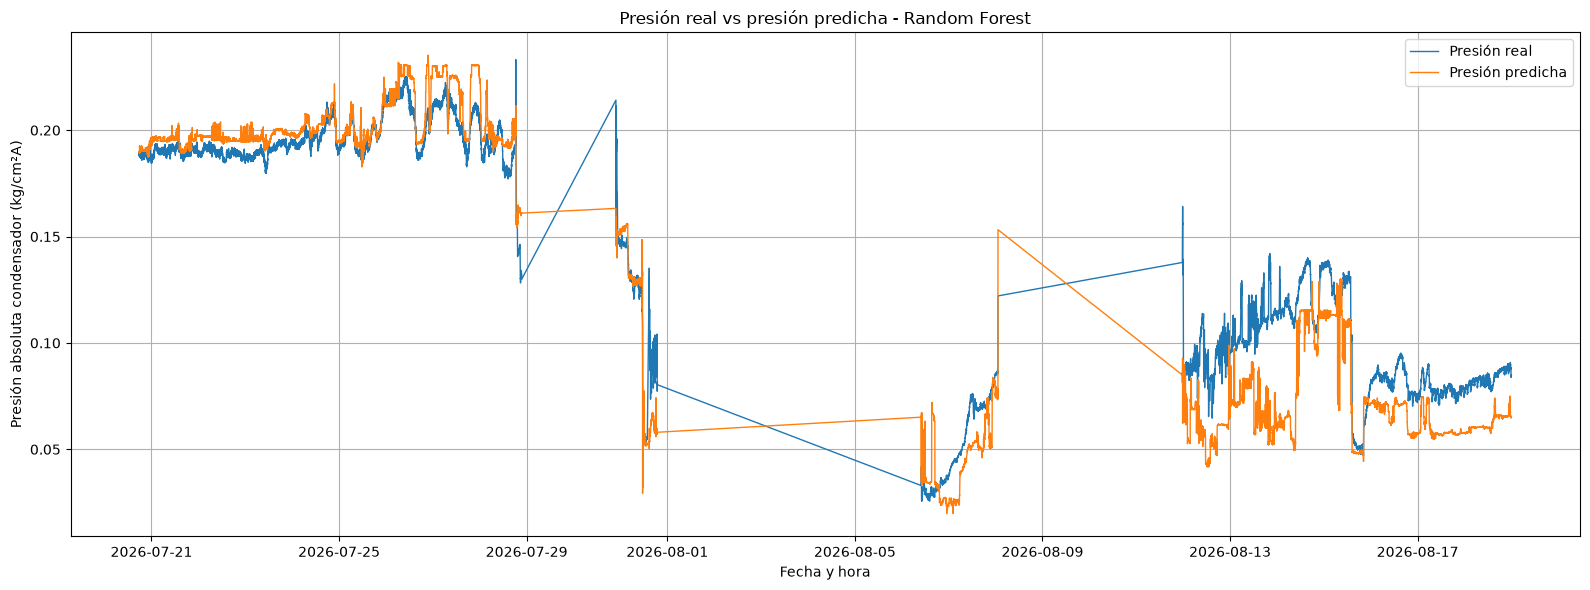

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))

plt.plot(
    test_vacio["FechaHora"],
    y_test.values,
    label="Presión real",
    linewidth=1
)

plt.plot(
    test_vacio["FechaHora"],
    y_pred,
    label="Presión predicha",
    linewidth=1
)

plt.xlabel("Fecha y hora")
plt.ylabel("Presión absoluta condensador (kg/cm²A)")
plt.title("Presión real vs presión predicha - Random Forest")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [36]:
resultado_vacio = test_vacio[
    ["FechaHora", "Presion_Condensador_kg_cm2A"]
].copy()

resultado_vacio["Presion_Predicha"] = y_pred

resultado_vacio["Error_Absoluto"] = abs(
    resultado_vacio["Presion_Condensador_kg_cm2A"]
    - resultado_vacio["Presion_Predicha"]
)

resultado_vacio.sort_values(
    "Error_Absoluto",
    ascending=False
).head(20)

,FechaHora,Presion_Condensador_kg_cm2A,Presion_Predicha,Error_Absoluto
117010,2026-08-11 23:44:00,0.164148,0.062158,0.101990
119673,2026-08-13 20:07:00,0.140949,0.052730,0.088220
119672,2026-08-13 20:06:00,0.139576,0.053288,0.086288
114391,2026-07-31 14:45:00,0.135150,0.050198,0.084952
119671,2026-08-13 20:05:00,0.136905,0.052708,0.084196
119660,2026-08-13 19:54:00,0.136523,0.052346,0.084177
119661,2026-08-13 19:55:00,0.136600,0.052651,0.083948
119674,2026-08-13 20:08:00,0.141102,0.058584,0.082518
119670,2026-08-13 20:04:00,0.134997,0.052631,0.082366
119659,2026-08-13 19:53:00,0.134310,0.052346,0.081965


In [37]:
# Agregar el error al conjunto de prueba
analisis_error = test_vacio.copy()

analisis_error["Presion_Predicha"] = y_pred

analisis_error["Error_Absoluto"] = abs(
    analisis_error["Presion_Condensador_kg_cm2A"]
    - analisis_error["Presion_Predicha"]
)

# Mostrar los 20 errores más grandes
columnas_error = [
    "FechaHora",
    "Presion_Condensador_kg_cm2A",
    "Presion_Predicha",
    "Error_Absoluto",
    "Flujo_Agua_Mar_m3_h",
    "Temp_Entrada_Agua_Mar_C",
    "Temp_Salida_Agua_Mar_C",
    "Presion_Entrada_Agua_Mar_kg_cm2",
    "Presion_MS_Eyectores_kg_cm2",
    "Temp_MS_Eyectores_C",
    "Flujo_Aire_Soplador_kg_h",
    "Presion_Descarga_Soplador_kg_cm2"
]

analisis_error[
    columnas_error
].sort_values(
    "Error_Absoluto",
    ascending=False
).head(20)

,FechaHora,Presion_Condensador_kg_cm2A,Presion_Predicha,Error_Absoluto,Flujo_Agua_Mar_m3_h,Temp_Entrada_Agua_Mar_C,Temp_Salida_Agua_Mar_C,Presion_Entrada_Agua_Mar_kg_cm2,Presion_MS_Eyectores_kg_cm2,Temp_MS_Eyectores_C,Flujo_Aire_Soplador_kg_h,Presion_Descarga_Soplador_kg_cm2
117010,2026-08-11 23:44:00,0.164148,0.062158,0.101990,3424.890137,22.214539,27.219063,5.444153,10.335067,271.990356,64409.523438,1.398962
119673,2026-08-13 20:07:00,0.140949,0.052730,0.088220,3264.165039,21.654072,29.093594,6.552019,10.488590,263.871094,99038.460938,2.258547
119672,2026-08-13 20:06:00,0.139576,0.053288,0.086288,3269.296387,21.646503,29.102715,6.557081,10.478498,263.883331,98950.164062,2.255800
114391,2026-07-31 14:45:00,0.135150,0.050198,0.084952,3607.364014,21.310986,25.074440,6.439102,11.129654,259.636292,144775.828125,1.583944
119671,2026-08-13 20:05:00,0.136905,0.052708,0.084196,3264.707275,21.648951,29.098267,6.551629,10.484797,263.874420,99052.375000,2.262820
119660,2026-08-13 19:54:00,0.136523,0.052346,0.084177,3256.113525,21.646509,29.054653,6.524724,10.747009,264.107941,99009.953125,2.261600
119661,2026-08-13 19:55:00,0.136600,0.052651,0.083948,3253.860840,21.643393,29.077572,6.534108,10.734043,264.092407,98949.468750,2.261905
119674,2026-08-13 20:08:00,0.141102,0.058584,0.082518,3261.606445,21.650068,29.121407,6.533291,10.508591,263.859985,99055.843750,2.260989
119670,2026-08-13 20:04:00,0.134997,0.052631,0.082366,3260.006836,21.649174,29.096706,6.558794,10.497152,263.883331,99199.078125,2.265873
119659,2026-08-13 19:53:00,0.134310,0.052346,0.081965,3263.720215,21.643393,29.045975,6.528656,10.771414,264.116852,98822.937500,2.263126


In [40]:
print("Máxima presión condensador en entrenamiento:")
print(
    train_vacio["Presion_Condensador_kg_cm2A"].max()
)

print("\nMáxima presión condensador en prueba:")
print(
    test_vacio["Presion_Condensador_kg_cm2A"].max()
)

print("\nPromedio entrenamiento:")
print(
    train_vacio["Presion_Condensador_kg_cm2A"].mean()
)

print("\nPromedio prueba:")
print(
    test_vacio["Presion_Condensador_kg_cm2A"].mean()
)

Máxima presión condensador en entrenamiento:
0.9263584017753601

Máxima presión condensador en prueba:
0.23321124911308289

Promedio entrenamiento:
0.09220313097065895

Promedio prueba:
0.13879320537565207


In [42]:
# ==========================================================
# 1. CREAR DATAFRAME DE ANÁLISIS DE ERRORES
# ==========================================================

analisis_error = test_vacio.copy()

# Agregar predicción
analisis_error["Presion_Predicha"] = y_pred

# Calcular error absoluto
analisis_error["Error_Absoluto"] = abs(
    analisis_error["Presion_Condensador_kg_cm2A"]
    - analisis_error["Presion_Predicha"]
)


# ==========================================================
# 2. TRAER VARIABLES QUE NO ESTABAN EN test_vacio
# ==========================================================

variables_adicionales = df_operacion[
    [
        "FechaHora",
        "Flujo_Vapor_Turbina_t_h",
        "DeltaT_Agua_Mar_C"
    ]
].copy()


# Unir utilizando FechaHora
analisis_error = analisis_error.merge(
    variables_adicionales,
    on="FechaHora",
    how="left"
)


# ==========================================================
# 3. COLUMNAS QUE QUEREMOS REVISAR
# ==========================================================

columnas_error = [
    "FechaHora",

    "Presion_Condensador_kg_cm2A",
    "Presion_Predicha",
    "Error_Absoluto",

    "Flujo_Vapor_Turbina_t_h",

    "Flujo_Agua_Mar_m3_h",
    "Temp_Entrada_Agua_Mar_C",
    "Temp_Salida_Agua_Mar_C",
    "DeltaT_Agua_Mar_C",

    "Presion_Entrada_Agua_Mar_kg_cm2",

    "Presion_MS_Eyectores_kg_cm2",
    "Temp_MS_Eyectores_C",

    "Flujo_Aire_Soplador_kg_h",
    "Presion_Descarga_Soplador_kg_cm2"
]


# ==========================================================
# 4. MOSTRAR LOS 20 ERRORES MÁS GRANDES
# ==========================================================

analisis_error[
    columnas_error
].sort_values(
    "Error_Absoluto",
    ascending=False
).head(20)

,FechaHora,Presion_Condensador_kg_cm2A,Presion_Predicha,Error_Absoluto,Flujo_Vapor_Turbina_t_h,Flujo_Agua_Mar_m3_h,Temp_Entrada_Agua_Mar_C,Temp_Salida_Agua_Mar_C,DeltaT_Agua_Mar_C,Presion_Entrada_Agua_Mar_kg_cm2,Presion_MS_Eyectores_kg_cm2,Temp_MS_Eyectores_C,Flujo_Aire_Soplador_kg_h,Presion_Descarga_Soplador_kg_cm2
15326,2026-08-11 23:44:00,0.164148,0.062158,0.101990,31.822056,3424.890137,22.214539,27.219063,5.004524,5.444153,10.335067,271.990356,64409.523438,1.398962
17989,2026-08-13 20:07:00,0.140949,0.052730,0.088220,35.217999,3264.165039,21.654072,29.093594,7.439522,6.552019,10.488590,263.871094,99038.460938,2.258547
17988,2026-08-13 20:06:00,0.139576,0.053288,0.086288,34.878596,3269.296387,21.646503,29.102715,7.456211,6.557081,10.478498,263.883331,98950.164062,2.255800
12707,2026-07-31 14:45:00,0.135150,0.050198,0.084952,29.894793,3607.364014,21.310986,25.074440,3.763454,6.439102,11.129654,259.636292,144775.828125,1.583944
17987,2026-08-13 20:05:00,0.136905,0.052708,0.084196,34.796352,3264.707275,21.648951,29.098267,7.449316,6.551629,10.484797,263.874420,99052.375000,2.262820
17976,2026-08-13 19:54:00,0.136523,0.052346,0.084177,34.758921,3256.113525,21.646509,29.054653,7.408144,6.524724,10.747009,264.107941,99009.953125,2.261600
17977,2026-08-13 19:55:00,0.136600,0.052651,0.083948,34.572649,3253.860840,21.643393,29.077572,7.434179,6.534108,10.734043,264.092407,98949.468750,2.261905
17990,2026-08-13 20:08:00,0.141102,0.058584,0.082518,34.926013,3261.606445,21.650068,29.121407,7.471338,6.533291,10.508591,263.859985,99055.843750,2.260989
17986,2026-08-13 20:04:00,0.134997,0.052631,0.082366,34.796965,3260.006836,21.649174,29.096706,7.447533,6.558794,10.497152,263.883331,99199.078125,2.265873
17975,2026-08-13 19:53:00,0.134310,0.052346,0.081965,34.435211,3263.720215,21.643393,29.045975,7.402582,6.528656,10.771414,264.116852,98822.937500,2.263126


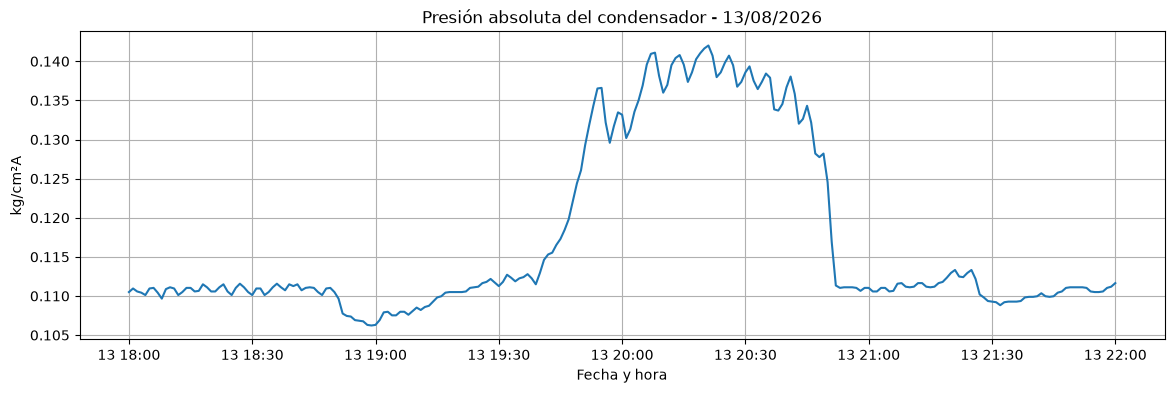

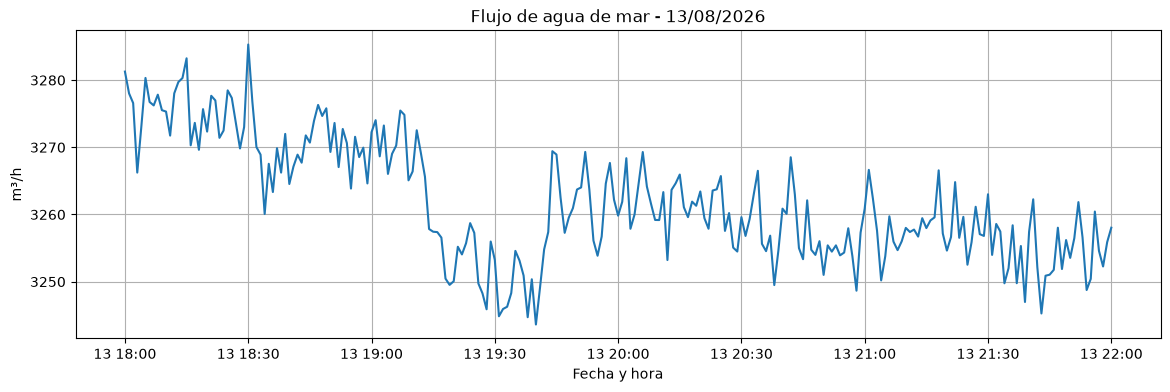

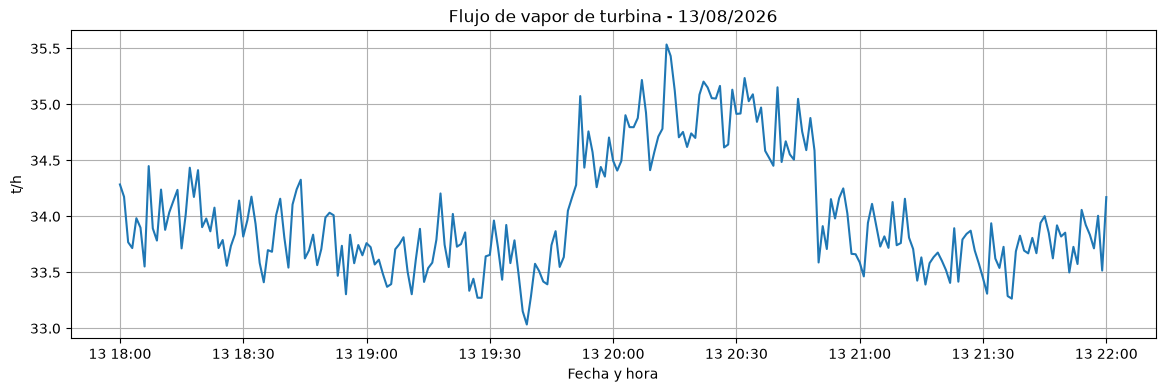

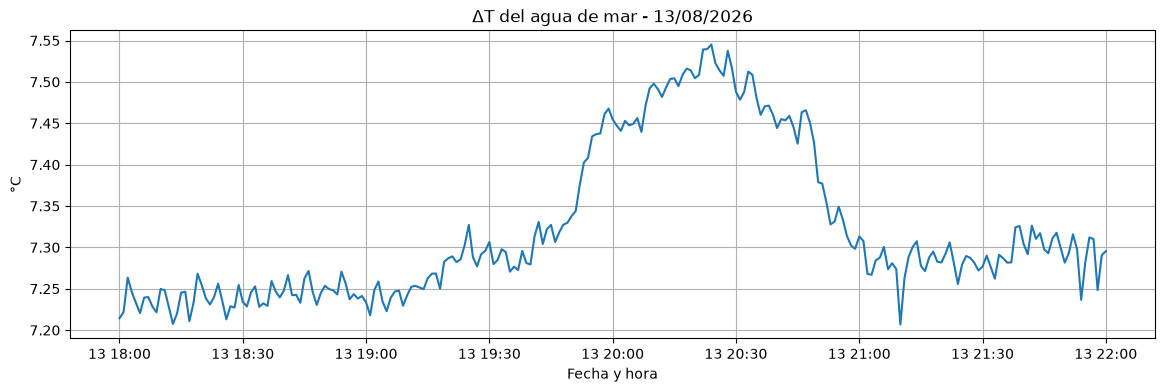

In [43]:
inicio = "2026-08-13 18:00"
fin    = "2026-08-13 22:00"

evento_13ago = df_operacion[
    (df_operacion["FechaHora"] >= inicio) &
    (df_operacion["FechaHora"] <= fin)
].copy()

import matplotlib.pyplot as plt

# Presión condensador
plt.figure(figsize=(14, 4))
plt.plot(
    evento_13ago["FechaHora"],
    evento_13ago["Presion_Condensador_kg_cm2A"]
)
plt.title("Presión absoluta del condensador - 13/08/2026")
plt.ylabel("kg/cm²A")
plt.xlabel("Fecha y hora")
plt.grid(True)
plt.show()

# Flujo de agua de mar
plt.figure(figsize=(14, 4))
plt.plot(
    evento_13ago["FechaHora"],
    evento_13ago["Flujo_Agua_Mar_m3_h"]
)
plt.title("Flujo de agua de mar - 13/08/2026")
plt.ylabel("m³/h")
plt.xlabel("Fecha y hora")
plt.grid(True)
plt.show()

# Flujo de vapor
plt.figure(figsize=(14, 4))
plt.plot(
    evento_13ago["FechaHora"],
    evento_13ago["Flujo_Vapor_Turbina_t_h"]
)
plt.title("Flujo de vapor de turbina - 13/08/2026")
plt.ylabel("t/h")
plt.xlabel("Fecha y hora")
plt.grid(True)
plt.show()

# Delta T agua de mar
plt.figure(figsize=(14, 4))
plt.plot(
    evento_13ago["FechaHora"],
    evento_13ago["DeltaT_Agua_Mar_C"]
)
plt.title("ΔT del agua de mar - 13/08/2026")
plt.ylabel("°C")
plt.xlabel("Fecha y hora")
plt.grid(True)
plt.show()

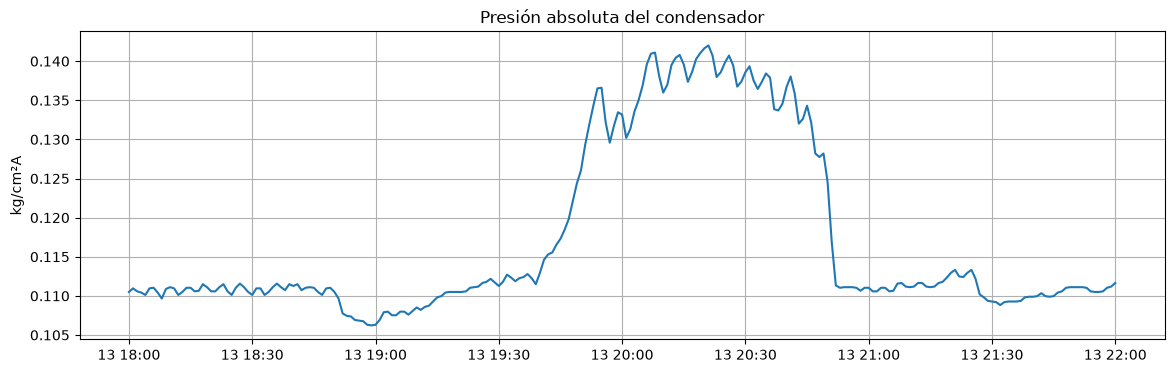

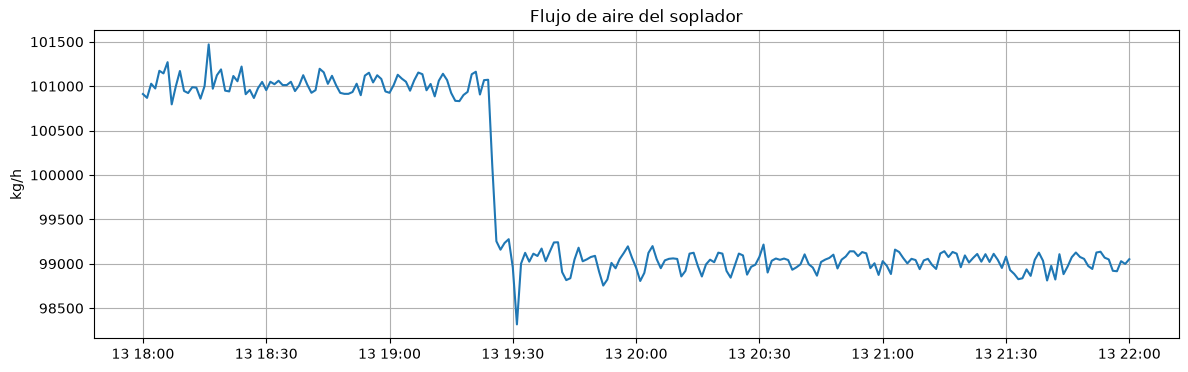

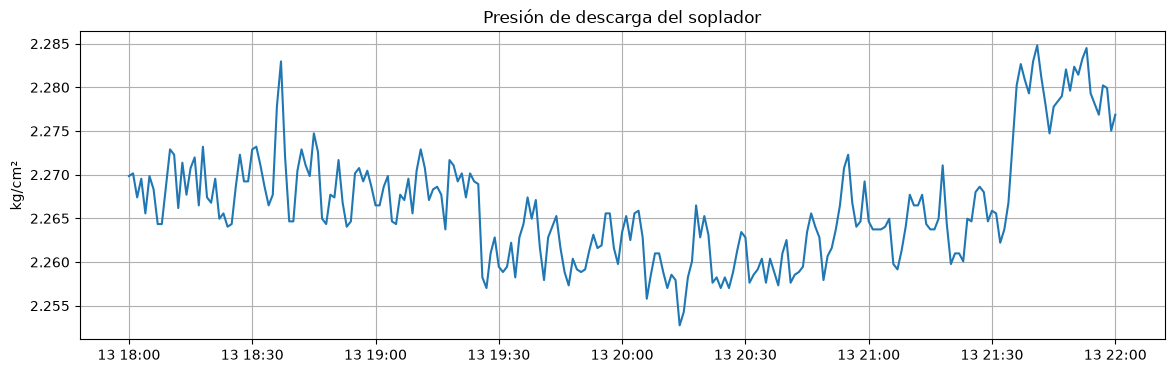

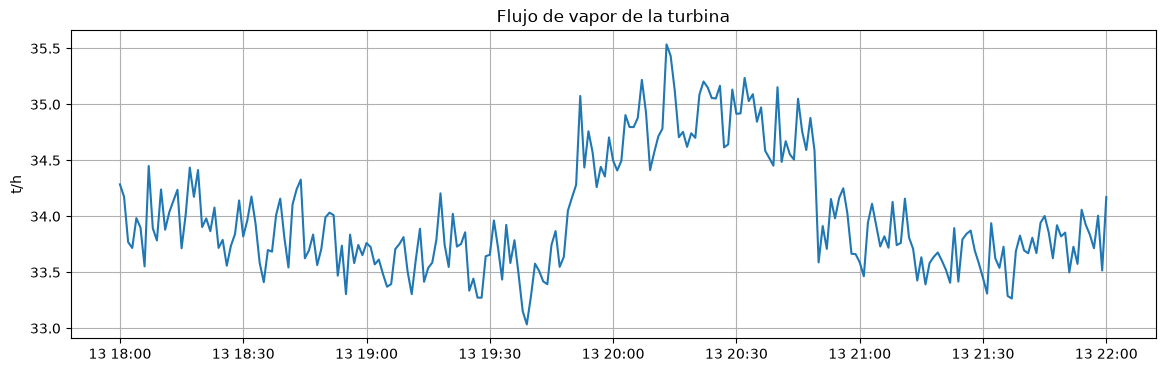

In [44]:
import matplotlib.pyplot as plt

inicio = "2026-08-13 18:00"
fin = "2026-08-13 22:00"

evento_13ago = df_operacion[
    (df_operacion["FechaHora"] >= inicio) &
    (df_operacion["FechaHora"] <= fin)
].copy()


# PRESIÓN DEL CONDENSADOR
plt.figure(figsize=(14, 4))
plt.plot(
    evento_13ago["FechaHora"],
    evento_13ago["Presion_Condensador_kg_cm2A"]
)
plt.title("Presión absoluta del condensador")
plt.ylabel("kg/cm²A")
plt.grid(True)
plt.show()


# FLUJO DE AIRE DEL SOPLADOR
plt.figure(figsize=(14, 4))
plt.plot(
    evento_13ago["FechaHora"],
    evento_13ago["Flujo_Aire_Soplador_kg_h"]
)
plt.title("Flujo de aire del soplador")
plt.ylabel("kg/h")
plt.grid(True)
plt.show()


# PRESIÓN DE DESCARGA DEL SOPLADOR
plt.figure(figsize=(14, 4))
plt.plot(
    evento_13ago["FechaHora"],
    evento_13ago["Presion_Descarga_Soplador_kg_cm2"]
)
plt.title("Presión de descarga del soplador")
plt.ylabel("kg/cm²")
plt.grid(True)
plt.show()


# FLUJO DE VAPOR DE LA TURBINA
plt.figure(figsize=(14, 4))
plt.plot(
    evento_13ago["FechaHora"],
    evento_13ago["Flujo_Vapor_Turbina_t_h"]
)
plt.title("Flujo de vapor de la turbina")
plt.ylabel("t/h")
plt.grid(True)
plt.show()

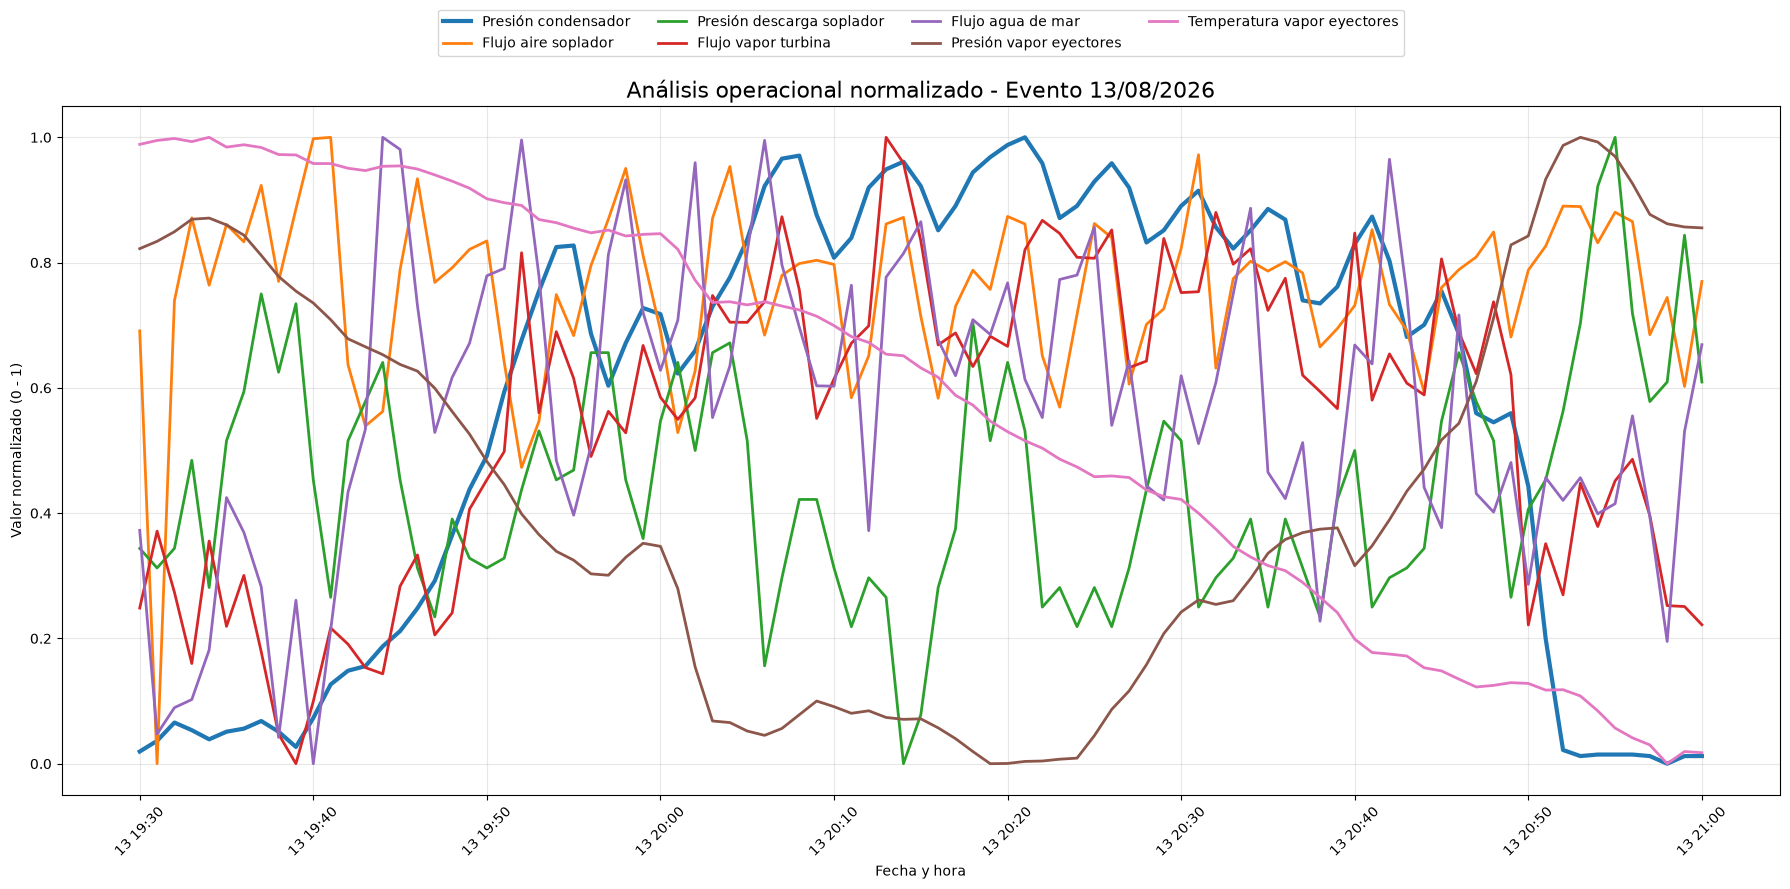

In [46]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# ============================================================
# EVENTO 13/08/2026
# ============================================================

inicio = "2026-08-13 19:30:00"
fin    = "2026-08-13 21:00:00"

evento_13 = df_operacion[
    (df_operacion["FechaHora"] >= inicio) &
    (df_operacion["FechaHora"] <= fin)
].copy()


# ============================================================
# VARIABLES QUE QUEREMOS ANALIZAR
# ============================================================

variables = [
    "Presion_Condensador_kg_cm2A",
    "Flujo_Aire_Soplador_kg_h",
    "Presion_Descarga_Soplador_kg_cm2",
    "Flujo_Vapor_Turbina_t_h",
    "Flujo_Agua_Mar_m3_h",
    "Presion_MS_Eyectores_kg_cm2",
    "Temp_MS_Eyectores_C"
]


# ============================================================
# NORMALIZAR VARIABLES ENTRE 0 Y 1
# ============================================================

scaler = MinMaxScaler()

evento_norm = evento_13.copy()

evento_norm[variables] = scaler.fit_transform(
    evento_13[variables]
)


# ============================================================
# GRÁFICA
# ============================================================

plt.figure(figsize=(18, 9))

plt.plot(
    evento_norm["FechaHora"],
    evento_norm["Presion_Condensador_kg_cm2A"],
    label="Presión condensador",
    linewidth=3
)

plt.plot(
    evento_norm["FechaHora"],
    evento_norm["Flujo_Aire_Soplador_kg_h"],
    label="Flujo aire soplador",
    linewidth=2
)

plt.plot(
    evento_norm["FechaHora"],
    evento_norm["Presion_Descarga_Soplador_kg_cm2"],
    label="Presión descarga soplador",
    linewidth=2
)

plt.plot(
    evento_norm["FechaHora"],
    evento_norm["Flujo_Vapor_Turbina_t_h"],
    label="Flujo vapor turbina",
    linewidth=2
)

plt.plot(
    evento_norm["FechaHora"],
    evento_norm["Flujo_Agua_Mar_m3_h"],
    label="Flujo agua de mar",
    linewidth=2
)

plt.plot(
    evento_norm["FechaHora"],
    evento_norm["Presion_MS_Eyectores_kg_cm2"],
    label="Presión vapor eyectores",
    linewidth=2
)

plt.plot(
    evento_norm["FechaHora"],
    evento_norm["Temp_MS_Eyectores_C"],
    label="Temperatura vapor eyectores",
    linewidth=2
)


plt.title(
    "Análisis operacional normalizado - Evento 13/08/2026",
    fontsize=16
)

plt.xlabel("Fecha y hora")
plt.ylabel("Valor normalizado (0 - 1)")

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=4
)

plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

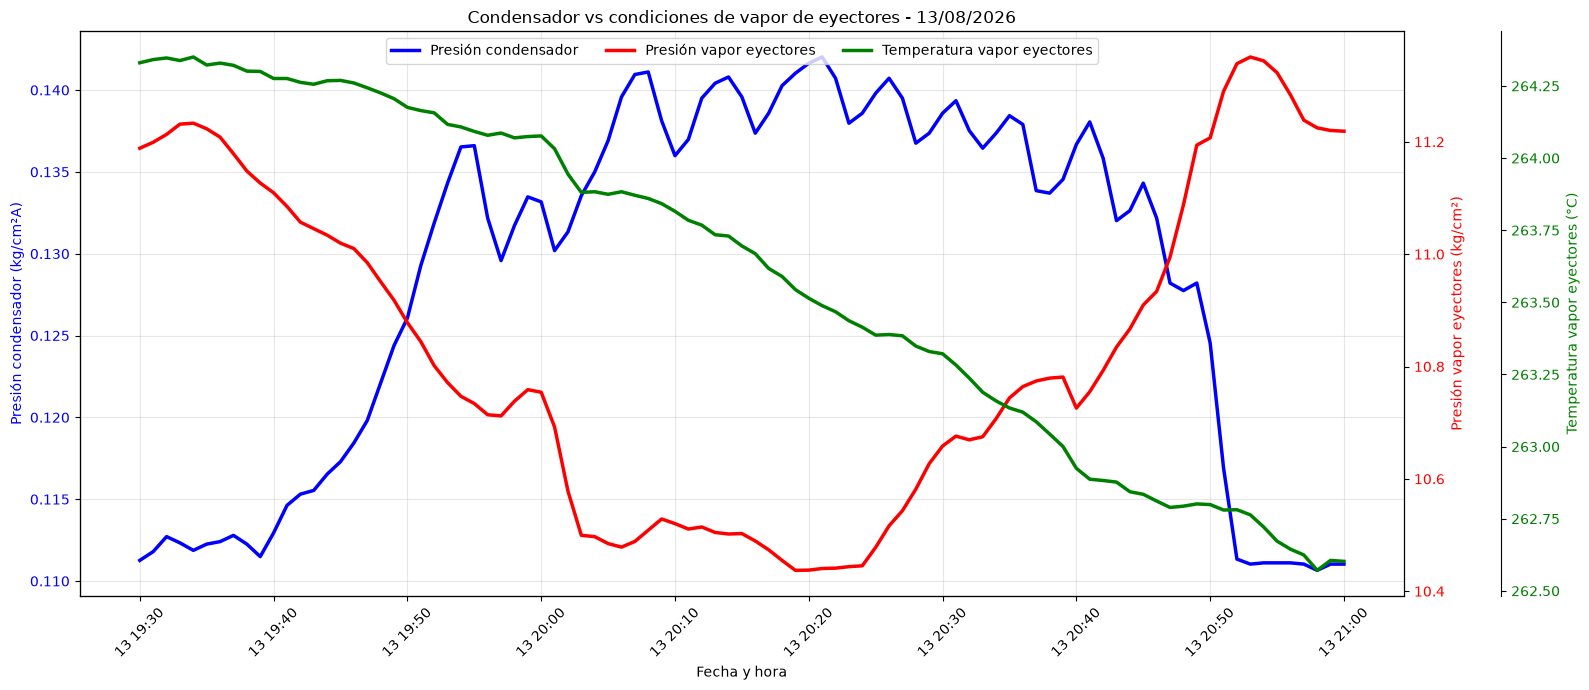

In [48]:
import matplotlib.pyplot as plt

evento = df_operacion[
    (df_operacion["FechaHora"] >= "2026-08-13 19:30:00") &
    (df_operacion["FechaHora"] <= "2026-08-13 21:00:00")
].copy()

fig, ax1 = plt.subplots(figsize=(16, 7))

# Presión absoluta del condensador
ax1.plot(
    evento["FechaHora"],
    evento["Presion_Condensador_kg_cm2A"],
    color="blue",
    linewidth=2.5,
    label="Presión condensador"
)

ax1.set_xlabel("Fecha y hora")
ax1.set_ylabel(
    "Presión condensador (kg/cm²A)",
    color="blue"
)

ax1.tick_params(
    axis="y",
    labelcolor="blue"
)

ax1.tick_params(
    axis="x",
    rotation=45
)


# Presión del vapor hacia eyectores
ax2 = ax1.twinx()

ax2.plot(
    evento["FechaHora"],
    evento["Presion_MS_Eyectores_kg_cm2"],
    color="red",
    linewidth=2.5,
    label="Presión vapor eyectores"
)

ax2.set_ylabel(
    "Presión vapor eyectores (kg/cm²)",
    color="red"
)

ax2.tick_params(
    axis="y",
    labelcolor="red"
)


# Temperatura del vapor hacia eyectores
ax3 = ax1.twinx()

ax3.spines["right"].set_position(
    ("outward", 70)
)

ax3.plot(
    evento["FechaHora"],
    evento["Temp_MS_Eyectores_C"],
    color="green",
    linewidth=2.5,
    label="Temperatura vapor eyectores"
)

ax3.set_ylabel(
    "Temperatura vapor eyectores (°C)",
    color="green"
)

ax3.tick_params(
    axis="y",
    labelcolor="green"
)


# Leyenda conjunta
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2 + lines3,
    labels1 + labels2 + labels3,
    loc="upper center",
    ncol=3
)

plt.title(
    "Condensador vs condiciones de vapor de eyectores - 13/08/2026"
)

ax1.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [49]:
df_lags = df_operacion.sort_values("FechaHora").copy()

# Lags de presión MS hacia eyectores
df_lags["P_Eyectores_lag5"] = (
    df_lags["Presion_MS_Eyectores_kg_cm2"].shift(5)
)

df_lags["P_Eyectores_lag10"] = (
    df_lags["Presion_MS_Eyectores_kg_cm2"].shift(10)
)

# Lags de temperatura MS hacia eyectores
df_lags["T_Eyectores_lag5"] = (
    df_lags["Temp_MS_Eyectores_C"].shift(5)
)

df_lags["T_Eyectores_lag10"] = (
    df_lags["Temp_MS_Eyectores_C"].shift(10)
)

# Lags del flujo de agua de mar
df_lags["Flujo_Agua_lag5"] = (
    df_lags["Flujo_Agua_Mar_m3_h"].shift(5)
)

df_lags["Flujo_Agua_lag10"] = (
    df_lags["Flujo_Agua_Mar_m3_h"].shift(10)
)

In [50]:
df_lags["Delta_Min"] = (
    df_lags["FechaHora"]
    .diff()
    .dt.total_seconds()
    .div(60)
)

In [51]:
df_lags["Nuevo_Bloque"] = (
    df_lags["Delta_Min"].isna() |
    (df_lags["Delta_Min"] > 1)
)

df_lags["Bloque_Operacion"] = (
    df_lags["Nuevo_Bloque"].cumsum()
)

In [52]:
df_lags["P_Eyectores_lag5"] = (
    df_lags
    .groupby("Bloque_Operacion")["Presion_MS_Eyectores_kg_cm2"]
    .shift(5)
)

df_lags["P_Eyectores_lag10"] = (
    df_lags
    .groupby("Bloque_Operacion")["Presion_MS_Eyectores_kg_cm2"]
    .shift(10)
)

df_lags["T_Eyectores_lag5"] = (
    df_lags
    .groupby("Bloque_Operacion")["Temp_MS_Eyectores_C"]
    .shift(5)
)

df_lags["T_Eyectores_lag10"] = (
    df_lags
    .groupby("Bloque_Operacion")["Temp_MS_Eyectores_C"]
    .shift(10)
)

df_lags["Flujo_Agua_lag5"] = (
    df_lags
    .groupby("Bloque_Operacion")["Flujo_Agua_Mar_m3_h"]
    .shift(5)
)

df_lags["Flujo_Agua_lag10"] = (
    df_lags
    .groupby("Bloque_Operacion")["Flujo_Agua_Mar_m3_h"]
    .shift(10)
)

In [53]:
df_lags = df_lags.dropna(
    subset=[
        "P_Eyectores_lag5",
        "P_Eyectores_lag10",
        "T_Eyectores_lag5",
        "T_Eyectores_lag10",
        "Flujo_Agua_lag5",
        "Flujo_Agua_lag10"
    ]
).copy()

In [54]:
variables_X_mejorado = [
    "Flujo_Agua_Mar_m3_h",
    "Temp_Entrada_Agua_Mar_C",
    "Temp_Salida_Agua_Mar_C",
    "Presion_Entrada_Agua_Mar_kg_cm2",

    "Presion_MS_Eyectores_kg_cm2",
    "Temp_MS_Eyectores_C",

    "P_Eyectores_lag5",
    "P_Eyectores_lag10",
    "T_Eyectores_lag5",
    "T_Eyectores_lag10",

    "Flujo_Agua_lag5",
    "Flujo_Agua_lag10",

    "Flujo_Aire_Soplador_kg_h",
    "Presion_Descarga_Soplador_kg_cm2"
]

objetivo = "Presion_Condensador_kg_cm2A"

In [55]:
df_lags = df_lags.sort_values(
    "FechaHora"
).reset_index(drop=True)

corte = int(len(df_lags) * 0.80)

train = df_lags.iloc[:corte]
test = df_lags.iloc[corte:]

X_train = train[variables_X_mejorado]
y_train = train[objetivo]

X_test = test[variables_X_mejorado]
y_test = test[objetivo]

In [56]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

modelo_rf_mejorado = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

modelo_rf_mejorado.fit(
    X_train,
    y_train
)

y_pred_mejorado = modelo_rf_mejorado.predict(
    X_test
)

mae_mejorado = mean_absolute_error(
    y_test,
    y_pred_mejorado
)

rmse_mejorado = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_mejorado
    )
)

r2_mejorado = r2_score(
    y_test,
    y_pred_mejorado
)

print("MODELO 1 MEJORADO")
print("------------------")
print("MAE:", mae_mejorado)
print("RMSE:", rmse_mejorado)
print("R²:", r2_mejorado)

MODELO 1 MEJORADO
------------------
MAE: 0.015350722186760613
RMSE: 0.020683076138275563
R²: 0.8691346575176939


In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# Trabajamos con una copia
df_lag = df_operacion.copy()

# Ordenar cronológicamente
df_lag = df_lag.sort_values("FechaHora").reset_index(drop=True)

# Variables
objetivo = "Presion_Condensador_kg_cm2A"

variables_eyectores = [
    "Presion_MS_Eyectores_kg_cm2",
    "Temp_MS_Eyectores_C"
]

# Lags que vamos a probar (minutos)
lags = [0, 1, 2, 3, 5, 10, 15, 20, 30]

resultados = []

for variable in variables_eyectores:

    for lag in lags:

        # shift(lag) = valor de la variable X minutos antes
        serie_lag = df_lag[variable].shift(lag)

        # Correlación con presión actual del condensador
        correlacion = df_lag[objetivo].corr(serie_lag)

        resultados.append({
            "Variable": variable,
            "Lag_min": lag,
            "Correlacion": correlacion,
            "Correlacion_Absoluta": abs(correlacion)
        })

# Convertir a DataFrame
resultados_lag = pd.DataFrame(resultados)

resultados_lag

,Variable,Lag_min,Correlacion,Correlacion_Absoluta
0,Presion_MS_Eyectores_kg_cm2,0,0.366414,0.366414
1,Presion_MS_Eyectores_kg_cm2,1,0.366181,0.366181
2,Presion_MS_Eyectores_kg_cm2,2,0.366233,0.366233
3,Presion_MS_Eyectores_kg_cm2,3,0.366330,0.366330
4,Presion_MS_Eyectores_kg_cm2,5,0.366680,0.366680
5,Presion_MS_Eyectores_kg_cm2,10,0.367960,0.367960
6,Presion_MS_Eyectores_kg_cm2,15,0.368605,0.368605
7,Presion_MS_Eyectores_kg_cm2,20,0.368635,0.368635
8,Presion_MS_Eyectores_kg_cm2,30,0.369321,0.369321
9,Temp_MS_Eyectores_C,0,0.284475,0.284475


In [58]:
mejores_lags = (
    resultados_lag
    .sort_values("Correlacion_Absoluta", ascending=False)
    .groupby("Variable")
    .first()
    .reset_index()
)

mejores_lags

,Variable,Lag_min,Correlacion,Correlacion_Absoluta
0,Presion_MS_Eyectores_kg_cm2,30,0.369321,0.369321
1,Temp_MS_Eyectores_C,0,0.284475,0.284475


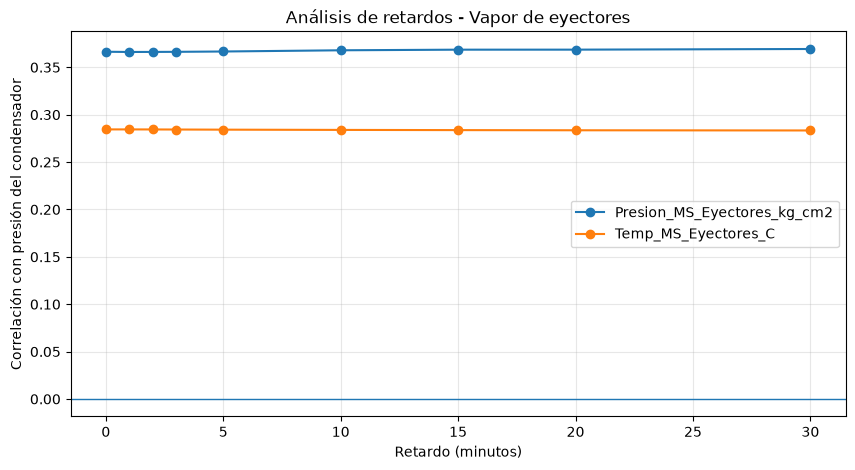

In [59]:
plt.figure(figsize=(10, 5))

for variable in variables_eyectores:

    datos = resultados_lag[
        resultados_lag["Variable"] == variable
    ]

    plt.plot(
        datos["Lag_min"],
        datos["Correlacion"],
        marker="o",
        label=variable
    )

plt.axhline(0, linewidth=1)

plt.xlabel("Retardo (minutos)")
plt.ylabel("Correlación con presión del condensador")
plt.title("Análisis de retardos - Vapor de eyectores")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

                           Variable  Importancia
0               Flujo_Agua_Mar_m3_h     0.843095
1            Temp_Salida_Agua_Mar_C     0.072217
2          Flujo_Aire_Soplador_kg_h     0.036855
3  Presion_Descarga_Soplador_kg_cm2     0.017601
4               Temp_MS_Eyectores_C     0.015564
5   Presion_Entrada_Agua_Mar_kg_cm2     0.009025
6           Temp_Entrada_Agua_Mar_C     0.004118
7       Presion_MS_Eyectores_kg_cm2     0.001524


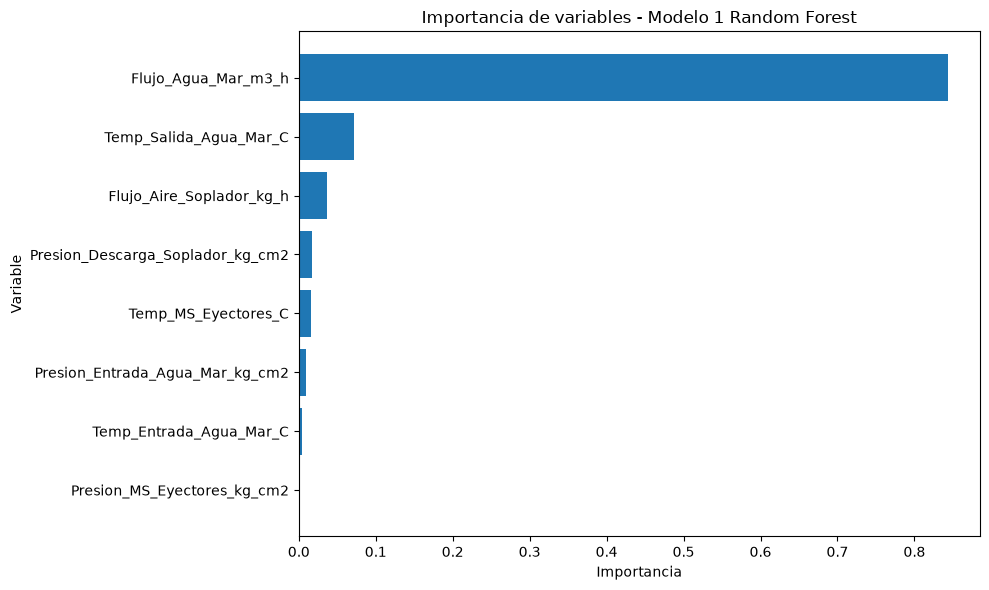

In [61]:
import pandas as pd
import matplotlib.pyplot as plt


# ==========================================================
# VARIABLES DEL MODELO 1 ORIGINAL
# ==========================================================

variables_X = [
    "Flujo_Agua_Mar_m3_h",
    "Temp_Entrada_Agua_Mar_C",
    "Temp_Salida_Agua_Mar_C",
    "Presion_Entrada_Agua_Mar_kg_cm2",
    "Presion_MS_Eyectores_kg_cm2",
    "Temp_MS_Eyectores_C",
    "Flujo_Aire_Soplador_kg_h",
    "Presion_Descarga_Soplador_kg_cm2"
]


# ==========================================================
# IMPORTANCIA DE VARIABLES
# MODELO 1 ORIGINAL
# ==========================================================

importancias = pd.DataFrame({
    "Variable": variables_X,
    "Importancia": modelo_rf_vacio.feature_importances_
})


# ==========================================================
# ORDENAR DE MAYOR A MENOR
# ==========================================================

importancias = (
    importancias
    .sort_values(
        "Importancia",
        ascending=False
    )
    .reset_index(drop=True)
)


print(importancias)


# ==========================================================
# GRÁFICA
# ==========================================================

plt.figure(figsize=(10, 6))

plt.barh(
    importancias["Variable"],
    importancias["Importancia"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importancia")
plt.ylabel("Variable")

plt.title(
    "Importancia de variables - Modelo 1 Random Forest"
)

plt.tight_layout()

plt.show()

In [63]:
# Ver exactamente con qué variables se entrenó el Modelo 1 original
print(modelo_rf_vacio.feature_names_in_)

['Flujo_Agua_Mar_m3_h' 'Temp_Entrada_Agua_Mar_C' 'Temp_Salida_Agua_Mar_C'
 'Presion_Entrada_Agua_Mar_kg_cm2' 'Presion_MS_Eyectores_kg_cm2'
 'Temp_MS_Eyectores_C' 'Flujo_Aire_Soplador_kg_h'
 'Presion_Descarga_Soplador_kg_cm2']


In [64]:
# ==========================================================
# RECONSTRUIR TEST DEL MODELO 1 ORIGINAL
# ==========================================================

variables_originales = list(
    modelo_rf_vacio.feature_names_in_
)

objetivo_original = "Presion_Condensador_kg_cm2A"


# Ordenar cronológicamente
df_modelo_original = (
    df_modelo_vacio
    .sort_values("FechaHora")
    .reset_index(drop=True)
)


# Mismo corte temporal 80 / 20
corte_original = int(
    len(df_modelo_original) * 0.80
)


# Reconstruir conjunto de prueba
X_test_original = df_modelo_original.loc[
    corte_original:,
    variables_originales
].copy()

y_test_original = df_modelo_original.loc[
    corte_original:,
    objetivo_original
].copy()


print("Variables del modelo:")
print(X_test_original.columns.tolist())

print("\nNúmero de registros:")
print(len(X_test_original))

print("\nNúmero de variables:")
print(X_test_original.shape[1])

Variables del modelo:
['Flujo_Agua_Mar_m3_h', 'Temp_Entrada_Agua_Mar_C', 'Temp_Salida_Agua_Mar_C', 'Presion_Entrada_Agua_Mar_kg_cm2', 'Presion_MS_Eyectores_kg_cm2', 'Temp_MS_Eyectores_C', 'Flujo_Aire_Soplador_kg_h', 'Presion_Descarga_Soplador_kg_cm2']

Número de registros:
25422

Número de variables:
8


                           Variable  Importancia  Desviacion
0               Flujo_Agua_Mar_m3_h     1.086106    0.006373
1            Temp_Salida_Agua_Mar_C     0.210241    0.001631
2   Presion_Entrada_Agua_Mar_kg_cm2     0.043026    0.000242
3          Flujo_Aire_Soplador_kg_h     0.034928    0.000915
4  Presion_Descarga_Soplador_kg_cm2     0.016253    0.000414
5       Presion_MS_Eyectores_kg_cm2     0.000733    0.000031
6               Temp_MS_Eyectores_C    -0.000230    0.000337
7           Temp_Entrada_Agua_Mar_C    -0.003974    0.000150


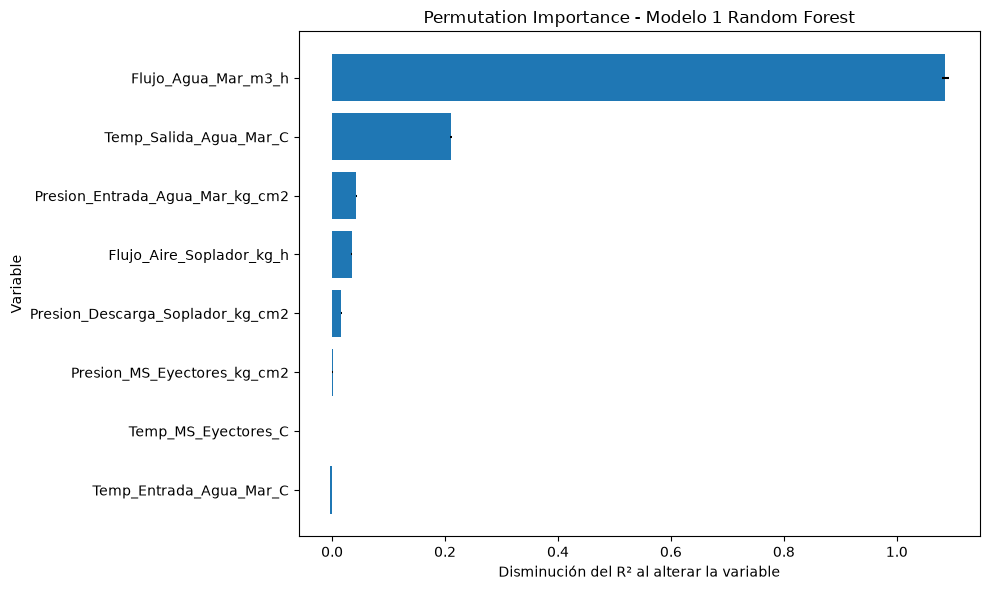

In [65]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt


resultado_perm = permutation_importance(
    modelo_rf_vacio,
    X_test_original,
    y_test_original,
    n_repeats=5,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)


perm_importancias = pd.DataFrame({
    "Variable": X_test_original.columns,
    "Importancia": resultado_perm.importances_mean,
    "Desviacion": resultado_perm.importances_std
})


perm_importancias = (
    perm_importancias
    .sort_values(
        "Importancia",
        ascending=False
    )
    .reset_index(drop=True)
)


print(perm_importancias)


# ==========================================================
# GRÁFICO
# ==========================================================

plt.figure(figsize=(10, 6))

plt.barh(
    perm_importancias["Variable"],
    perm_importancias["Importancia"],
    xerr=perm_importancias["Desviacion"]
)

plt.gca().invert_yaxis()

plt.xlabel(
    "Disminución del R² al alterar la variable"
)

plt.ylabel("Variable")

plt.title(
    "Permutation Importance - Modelo 1 Random Forest"
)

plt.tight_layout()

plt.show()

In [66]:
# ============================================================
# DETECCIÓN DE ANOMALÍAS SEGÚN EL ERROR DEL MODELO 1
# ============================================================

# Copia para trabajar sin modificar el dataframe original
eventos = analisis_error.copy()

# ------------------------------------------------------------
# 1. Calcular el umbral de anomalía
#    Percentil 95 = errores pertenecientes al 5% más alto
# ------------------------------------------------------------

umbral_error = eventos["Error_Absoluto"].quantile(0.95)

print("Umbral de error (percentil 95):")
print(umbral_error)

# ------------------------------------------------------------
# 2. Seleccionar solamente anomalías
# ------------------------------------------------------------

anomalias = eventos[
    eventos["Error_Absoluto"] >= umbral_error
].copy()

# Ordenar cronológicamente
anomalias = anomalias.sort_values("FechaHora")

print("\nCantidad total de registros:", len(eventos))
print("Cantidad de anomalías:", len(anomalias))

# ------------------------------------------------------------
# 3. Mostrar las anomalías más importantes
# ------------------------------------------------------------

columnas_mostrar = [
    "FechaHora",
    "Presion_Condensador_kg_cm2A",
    "Presion_Predicha",
    "Error_Absoluto",
    "Flujo_Agua_Mar_m3_h",
    "Temp_Salida_Agua_Mar_C",
    "Presion_Entrada_Agua_Mar_kg_cm2",
    "Flujo_Aire_Soplador_kg_h",
    "Presion_Descarga_Soplador_kg_cm2",
    "Presion_MS_Eyectores_kg_cm2",
    "Temp_MS_Eyectores_C"
]

anomalias[
    columnas_mostrar
].sort_values(
    "Error_Absoluto",
    ascending=False
).head(30)

Umbral de error (percentil 95):
0.04789252617748098

Cantidad total de registros: 25422
Cantidad de anomalías: 1272


,FechaHora,Presion_Condensador_kg_cm2A,Presion_Predicha,Error_Absoluto,Flujo_Agua_Mar_m3_h,Temp_Salida_Agua_Mar_C,Presion_Entrada_Agua_Mar_kg_cm2,Flujo_Aire_Soplador_kg_h,Presion_Descarga_Soplador_kg_cm2,Presion_MS_Eyectores_kg_cm2,Temp_MS_Eyectores_C
15326,2026-08-11 23:44:00,0.164148,0.062158,0.101990,3424.890137,27.219063,5.444153,64409.523438,1.398962,10.335067,271.990356
17989,2026-08-13 20:07:00,0.140949,0.052730,0.088220,3264.165039,29.093594,6.552019,99038.460938,2.258547,10.488590,263.871094
17988,2026-08-13 20:06:00,0.139576,0.053288,0.086288,3269.296387,29.102715,6.557081,98950.164062,2.255800,10.478498,263.883331
12707,2026-07-31 14:45:00,0.135150,0.050198,0.084952,3607.364014,25.074440,6.439102,144775.828125,1.583944,11.129654,259.636292
17987,2026-08-13 20:05:00,0.136905,0.052708,0.084196,3264.707275,29.098267,6.551629,99052.375000,2.262820,10.484797,263.874420
17976,2026-08-13 19:54:00,0.136523,0.052346,0.084177,3256.113525,29.054653,6.524724,99009.953125,2.261600,10.747009,264.107941
17977,2026-08-13 19:55:00,0.136600,0.052651,0.083948,3253.860840,29.077572,6.534108,98949.468750,2.261905,10.734043,264.092407
17990,2026-08-13 20:08:00,0.141102,0.058584,0.082518,3261.606445,29.121407,6.533291,99055.843750,2.260989,10.508591,263.859985
17986,2026-08-13 20:04:00,0.134997,0.052631,0.082366,3260.006836,29.096706,6.558794,99199.078125,2.265873,10.497152,263.883331
17975,2026-08-13 19:53:00,0.134310,0.052346,0.081965,3263.720215,29.045975,6.528656,98822.937500,2.263126,10.771414,264.116852


In [67]:
# ============================================================
# AGRUPAR ANOMALÍAS EN EVENTOS OPERACIONALES
# ============================================================

import pandas as pd

# Asegurar formato fecha
anomalias["FechaHora"] = pd.to_datetime(anomalias["FechaHora"])

# Ordenar cronológicamente
anomalias = anomalias.sort_values("FechaHora").copy()

# ------------------------------------------------------------
# 1. Tiempo desde la anomalía anterior
# ------------------------------------------------------------

anomalias["Diferencia_min"] = (
    anomalias["FechaHora"].diff().dt.total_seconds() / 60
)

# ------------------------------------------------------------
# 2. Crear nuevo evento cuando pasan más de 30 minutos
# ------------------------------------------------------------

anomalias["Nuevo_Evento"] = (
    anomalias["Diferencia_min"].isna()
    | (anomalias["Diferencia_min"] > 30)
)

# Numerar eventos
anomalias["Evento"] = anomalias["Nuevo_Evento"].cumsum()

# ------------------------------------------------------------
# 3. Resumen de cada evento
# ------------------------------------------------------------

resumen_eventos = (
    anomalias
    .groupby("Evento")
    .agg(
        Inicio=("FechaHora", "min"),
        Fin=("FechaHora", "max"),

        Numero_Registros=("FechaHora", "count"),

        Error_Maximo=("Error_Absoluto", "max"),
        Error_Promedio=("Error_Absoluto", "mean"),

        Presion_Maxima=(
            "Presion_Condensador_kg_cm2A",
            "max"
        ),

        Presion_Predicha_Promedio=(
            "Presion_Predicha",
            "mean"
        ),

        Flujo_Agua_Mar_Promedio=(
            "Flujo_Agua_Mar_m3_h",
            "mean"
        ),

        Temp_Salida_Agua_Promedio=(
            "Temp_Salida_Agua_Mar_C",
            "mean"
        ),

        Presion_MS_Eyectores_Promedio=(
            "Presion_MS_Eyectores_kg_cm2",
            "mean"
        ),

        Temp_MS_Eyectores_Promedio=(
            "Temp_MS_Eyectores_C",
            "mean"
        ),

        Flujo_Aire_Soplador_Promedio=(
            "Flujo_Aire_Soplador_kg_h",
            "mean"
        ),

        Presion_Descarga_Soplador_Promedio=(
            "Presion_Descarga_Soplador_kg_cm2",
            "mean"
        )
    )
    .reset_index()
)

# ------------------------------------------------------------
# 4. Calcular duración
# ------------------------------------------------------------

resumen_eventos["Duracion_min"] = (
    resumen_eventos["Fin"] -
    resumen_eventos["Inicio"]
).dt.total_seconds() / 60

# ------------------------------------------------------------
# 5. Ordenar por error máximo
# ------------------------------------------------------------

resumen_eventos = resumen_eventos.sort_values(
    "Error_Maximo",
    ascending=False
)

resumen_eventos

,Evento,Inicio,Fin,Numero_Registros,Error_Maximo,Error_Promedio,Presion_Maxima,Presion_Predicha_Promedio,Flujo_Agua_Mar_Promedio,Temp_Salida_Agua_Promedio,Presion_MS_Eyectores_Promedio,Temp_MS_Eyectores_Promedio,Flujo_Aire_Soplador_Promedio,Presion_Descarga_Soplador_Promedio,Duracion_min
3,4,2026-08-11 23:34:00,2026-08-11 23:54:00,16,0.101990,0.062577,0.164148,0.088069,3452.165710,27.038790,10.516512,271.928516,63875.294678,1.287450,20.0
10,11,2026-08-13 15:27:00,2026-08-14 09:32:00,981,0.088220,0.056553,0.142018,0.059806,3272.938479,29.129809,11.095031,262.288882,99325.514582,2.282604,1085.0
2,3,2026-07-31 14:44:00,2026-07-31 15:15:00,15,0.084952,0.059765,0.135150,0.055269,3612.800277,25.317950,11.281798,259.643264,105901.906250,1.187810,31.0
1,2,2026-07-31 11:20:00,2026-07-31 11:23:00,4,0.066122,0.055640,0.095391,0.031547,3179.832520,26.425813,11.348438,260.383614,89395.322266,1.255113,3.0
9,10,2026-08-13 12:11:00,2026-08-13 14:00:00,59,0.061854,0.053456,0.122482,0.060417,3464.992477,28.268751,11.002587,258.106243,103046.906912,2.256674,109.0
4,5,2026-08-12 08:46:00,2026-08-12 10:53:00,89,0.059209,0.052432,0.113858,0.056779,3645.177921,26.022402,10.791178,267.630711,99282.707602,1.397405,127.0
8,9,2026-08-13 05:34:00,2026-08-13 06:09:00,27,0.056107,0.050884,0.129274,0.074563,3287.219112,28.617804,10.756374,243.817396,103051.622106,2.174275,35.0
0,1,2026-07-30 21:41:00,2026-07-30 22:10:00,13,0.053560,0.051127,0.214133,0.149857,2361.429068,29.255684,10.655380,256.412652,78054.539663,1.483047,29.0
5,6,2026-08-12 11:40:00,2026-08-12 12:54:00,44,0.053223,0.050354,0.096917,0.042840,4099.686934,25.664761,11.154106,260.416440,92014.842507,1.508665,74.0
7,8,2026-08-12 21:02:00,2026-08-12 21:13:00,12,0.052651,0.049996,0.113935,0.061236,3421.059102,27.106244,10.558368,258.544612,97020.134766,2.053851,11.0


In [68]:
# ============================================================
# REAGRUPAR ANOMALÍAS CON CRITERIO MÁS ESTRICTO
# ============================================================

anomalias = anomalias.sort_values("FechaHora").copy()

anomalias["Diferencia_min"] = (
    anomalias["FechaHora"].diff().dt.total_seconds() / 60
)

# Nuevo evento si pasan más de 10 minutos
anomalias["Nuevo_Evento"] = (
    anomalias["Diferencia_min"].isna()
    | (anomalias["Diferencia_min"] > 10)
)

anomalias["Evento"] = anomalias["Nuevo_Evento"].cumsum()

# Resumen
resumen_eventos = (
    anomalias
    .groupby("Evento")
    .agg(
        Inicio=("FechaHora", "min"),
        Fin=("FechaHora", "max"),
        Numero_Registros=("FechaHora", "count"),

        Error_Maximo=("Error_Absoluto", "max"),
        Error_Promedio=("Error_Absoluto", "mean"),

        Presion_Maxima=("Presion_Condensador_kg_cm2A", "max"),
        Presion_Predicha_Promedio=("Presion_Predicha", "mean"),

        Flujo_Agua_Mar_Promedio=("Flujo_Agua_Mar_m3_h", "mean"),
        Temp_Salida_Agua_Promedio=("Temp_Salida_Agua_Mar_C", "mean"),

        Presion_MS_Eyectores_Promedio=(
            "Presion_MS_Eyectores_kg_cm2", "mean"
        ),

        Temp_MS_Eyectores_Promedio=(
            "Temp_MS_Eyectores_C", "mean"
        ),

        Flujo_Aire_Soplador_Promedio=(
            "Flujo_Aire_Soplador_kg_h", "mean"
        ),

        Presion_Descarga_Soplador_Promedio=(
            "Presion_Descarga_Soplador_kg_cm2", "mean"
        )
    )
    .reset_index()
)

# Duración
resumen_eventos["Duracion_min"] = (
    resumen_eventos["Fin"] - resumen_eventos["Inicio"]
).dt.total_seconds() / 60

# Ordenar por mayor error
resumen_eventos = resumen_eventos.sort_values(
    "Error_Maximo",
    ascending=False
)

resumen_eventos

,Evento,Inicio,Fin,Numero_Registros,Error_Maximo,Error_Promedio,Presion_Maxima,Presion_Predicha_Promedio,Flujo_Agua_Mar_Promedio,Temp_Salida_Agua_Promedio,Presion_MS_Eyectores_Promedio,Temp_MS_Eyectores_Promedio,Flujo_Aire_Soplador_Promedio,Presion_Descarga_Soplador_Promedio,Duracion_min
4,5,2026-08-11 23:34:00,2026-08-11 23:54:00,16,0.101990,0.062577,0.164148,0.088069,3452.165710,27.038790,10.516512,271.928516,63875.294678,1.287450,20.0
19,20,2026-08-13 19:25:00,2026-08-14 09:32:00,830,0.088220,0.056808,0.142018,0.059491,3270.858175,29.174541,11.101806,262.341872,99024.996762,2.285082,847.0
2,3,2026-07-31 14:44:00,2026-07-31 14:58:00,14,0.084952,0.060601,0.135150,0.055149,3612.480382,25.299871,11.283372,259.673865,107794.425223,1.183717,14.0
17,18,2026-08-13 15:27:00,2026-08-13 18:51:00,150,0.070027,0.055199,0.132937,0.061547,3284.452176,28.883823,11.056438,261.982854,100977.982500,2.268958,204.0
1,2,2026-07-31 11:20:00,2026-07-31 11:23:00,4,0.066122,0.055640,0.095391,0.031547,3179.832520,26.425813,11.348438,260.383614,89395.322266,1.255113,3.0
13,14,2026-08-13 12:11:00,2026-08-13 12:33:00,22,0.061854,0.056015,0.119353,0.057927,3484.774847,28.172086,11.099060,254.063619,103055.261364,2.237540,22.0
5,6,2026-08-12 08:46:00,2026-08-12 10:26:00,86,0.059209,0.052539,0.113858,0.056788,3629.221947,26.047296,10.780082,267.705235,99432.102017,1.397422,100.0
14,15,2026-08-13 12:46:00,2026-08-13 13:00:00,15,0.058836,0.054148,0.115766,0.057166,3505.302620,28.144928,11.095356,259.077214,103059.059896,2.262271,14.0
12,13,2026-08-13 05:34:00,2026-08-13 06:09:00,27,0.056107,0.050884,0.129274,0.074563,3287.219112,28.617804,10.756374,243.817396,103051.622106,2.174275,35.0
15,16,2026-08-13 13:17:00,2026-08-13 13:38:00,17,0.053846,0.050649,0.122482,0.066428,3414.070384,28.473378,10.715298,261.654126,103025.709099,2.268656,21.0


Registros: 57


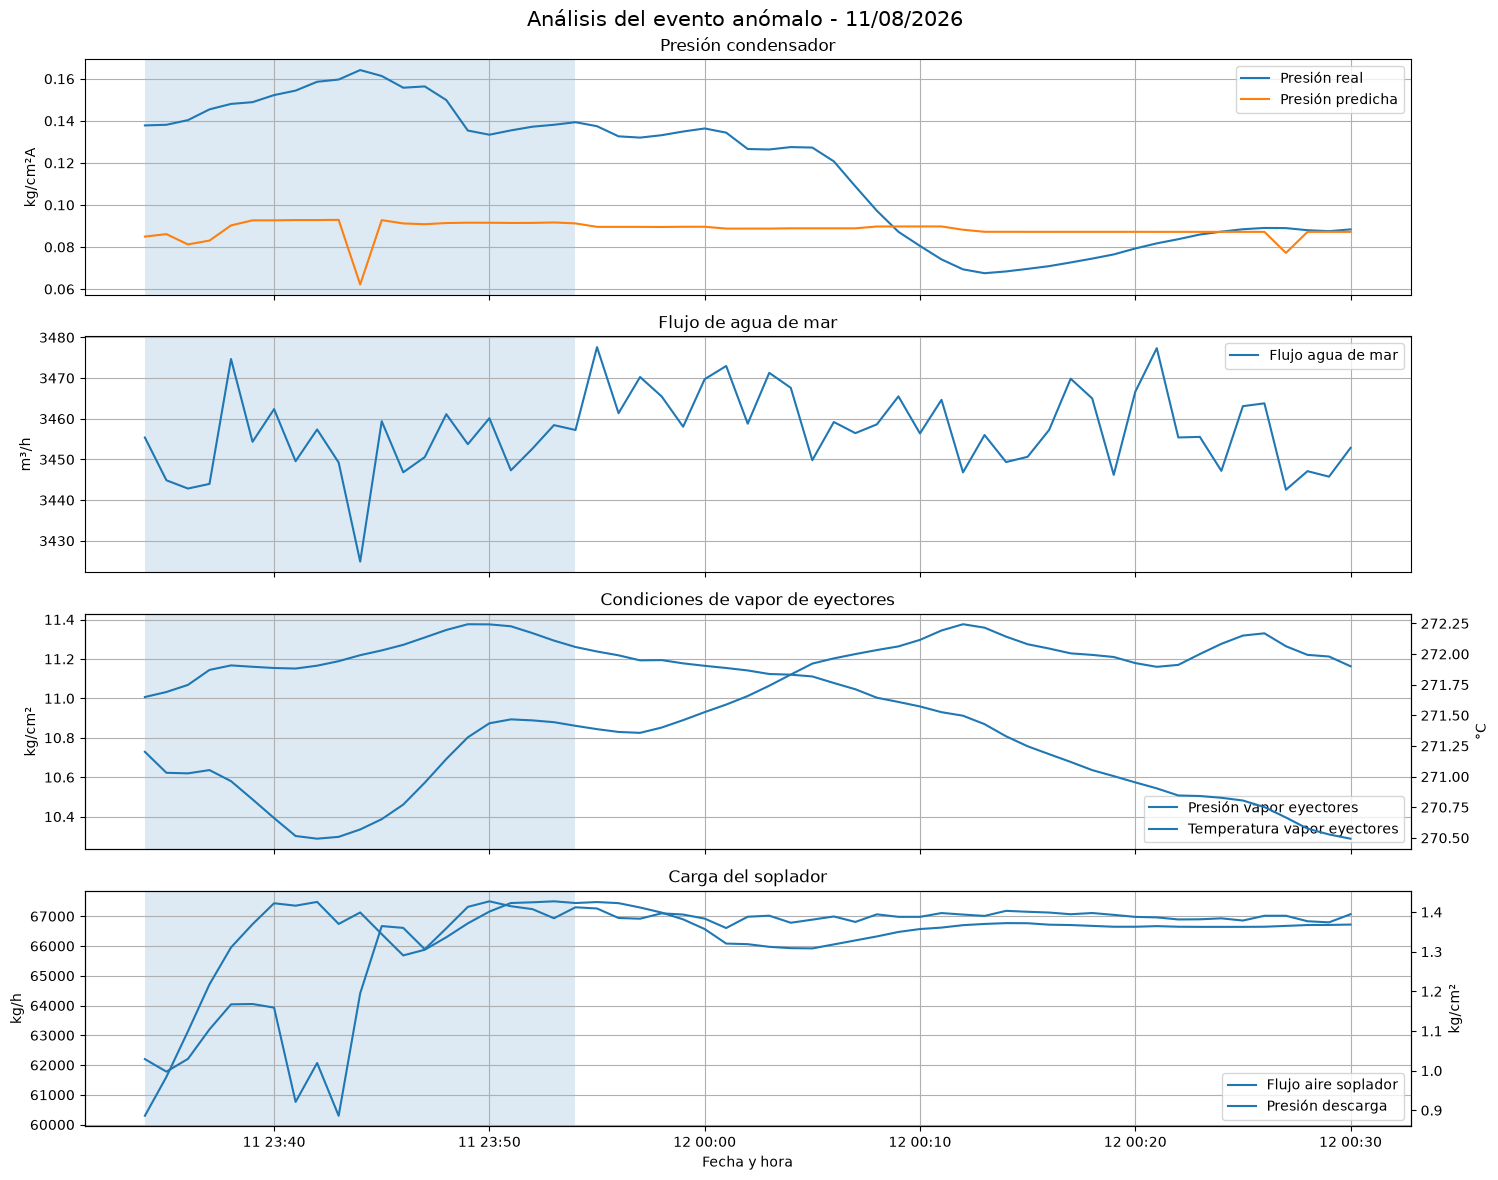

In [69]:
# ============================================================
# ANÁLISIS EVENTO 11/08/2026
# Ventana: 23:00 - 00:30
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Seleccionar ventana
evento_11 = analisis_error[
    (analisis_error["FechaHora"] >= "2026-08-11 23:00:00") &
    (analisis_error["FechaHora"] <= "2026-08-12 00:30:00")
].copy()

evento_11 = evento_11.sort_values("FechaHora")

print("Registros:", len(evento_11))

# ============================================================
# GRÁFICO
# ============================================================

fig, axes = plt.subplots(
    4, 1,
    figsize=(15, 12),
    sharex=True
)

# ------------------------------------------------------------
# 1. Presión real vs predicha
# ------------------------------------------------------------

axes[0].plot(
    evento_11["FechaHora"],
    evento_11["Presion_Condensador_kg_cm2A"],
    label="Presión real"
)

axes[0].plot(
    evento_11["FechaHora"],
    evento_11["Presion_Predicha"],
    label="Presión predicha"
)

axes[0].set_ylabel("kg/cm²A")
axes[0].set_title("Presión condensador")
axes[0].legend()
axes[0].grid(True)


# ------------------------------------------------------------
# 2. Sistema de agua de mar
# ------------------------------------------------------------

axes[1].plot(
    evento_11["FechaHora"],
    evento_11["Flujo_Agua_Mar_m3_h"],
    label="Flujo agua de mar"
)

axes[1].set_ylabel("m³/h")
axes[1].set_title("Flujo de agua de mar")
axes[1].legend()
axes[1].grid(True)


# ------------------------------------------------------------
# 3. Vapor de eyectores
# ------------------------------------------------------------

ax3 = axes[2]

ax3.plot(
    evento_11["FechaHora"],
    evento_11["Presion_MS_Eyectores_kg_cm2"],
    label="Presión vapor eyectores"
)

ax3.set_ylabel("kg/cm²")
ax3.set_title("Condiciones de vapor de eyectores")
ax3.grid(True)

ax3b = ax3.twinx()

ax3b.plot(
    evento_11["FechaHora"],
    evento_11["Temp_MS_Eyectores_C"],
    label="Temperatura vapor eyectores"
)

ax3b.set_ylabel("°C")

# Leyenda conjunta
lineas1, etiquetas1 = ax3.get_legend_handles_labels()
lineas2, etiquetas2 = ax3b.get_legend_handles_labels()

ax3.legend(
    lineas1 + lineas2,
    etiquetas1 + etiquetas2,
    loc="best"
)


# ------------------------------------------------------------
# 4. Soplador
# ------------------------------------------------------------

ax4 = axes[3]

ax4.plot(
    evento_11["FechaHora"],
    evento_11["Flujo_Aire_Soplador_kg_h"],
    label="Flujo aire soplador"
)

ax4.set_ylabel("kg/h")
ax4.set_title("Carga del soplador")
ax4.grid(True)

ax4b = ax4.twinx()

ax4b.plot(
    evento_11["FechaHora"],
    evento_11["Presion_Descarga_Soplador_kg_cm2"],
    label="Presión descarga"
)

ax4b.set_ylabel("kg/cm²")

lineas1, etiquetas1 = ax4.get_legend_handles_labels()
lineas2, etiquetas2 = ax4b.get_legend_handles_labels()

ax4.legend(
    lineas1 + lineas2,
    etiquetas1 + etiquetas2,
    loc="best"
)


# ------------------------------------------------------------
# Marcar período detectado como anómalo
# ------------------------------------------------------------

for ax in axes:

    ax.axvspan(
        pd.Timestamp("2026-08-11 23:34"),
        pd.Timestamp("2026-08-11 23:54"),
        alpha=0.15
    )

axes[-1].set_xlabel("Fecha y hora")

plt.suptitle(
    "Análisis del evento anómalo - 11/08/2026",
    fontsize=15
)

plt.tight_layout()

plt.show()

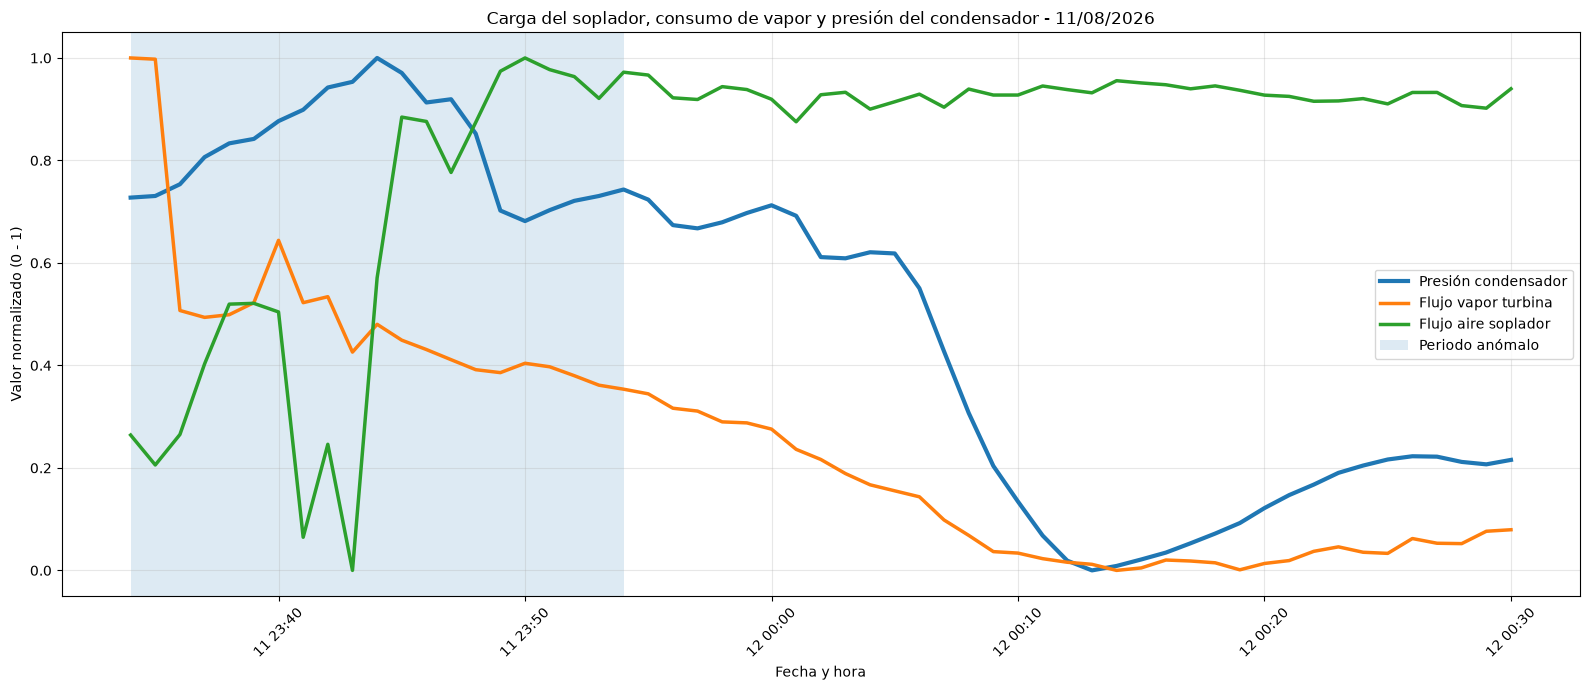

In [70]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# ============================================================
# EVENTO 11/08/2026
# ============================================================

inicio = "2026-08-11 23:30:00"
fin    = "2026-08-12 00:30:00"

evento_11 = df_operacion[
    (df_operacion["FechaHora"] >= inicio) &
    (df_operacion["FechaHora"] <= fin)
].copy()

# ============================================================
# VARIABLES
# ============================================================

variables = [
    "Presion_Condensador_kg_cm2A",
    "Flujo_Vapor_Turbina_t_h",
    "Flujo_Aire_Soplador_kg_h"
]

# ============================================================
# NORMALIZAR ENTRE 0 Y 1
# ============================================================

scaler = MinMaxScaler()

evento_norm = evento_11.copy()

evento_norm[variables] = scaler.fit_transform(
    evento_11[variables]
)

# ============================================================
# GRÁFICA
# ============================================================

plt.figure(figsize=(16, 7))

plt.plot(
    evento_norm["FechaHora"],
    evento_norm["Presion_Condensador_kg_cm2A"],
    label="Presión condensador",
    linewidth=3
)

plt.plot(
    evento_norm["FechaHora"],
    evento_norm["Flujo_Vapor_Turbina_t_h"],
    label="Flujo vapor turbina",
    linewidth=2.5
)

plt.plot(
    evento_norm["FechaHora"],
    evento_norm["Flujo_Aire_Soplador_kg_h"],
    label="Flujo aire soplador",
    linewidth=2.5
)

# Marcar el periodo anómalo detectado
plt.axvspan(
    pd.Timestamp("2026-08-11 23:34:00"),
    pd.Timestamp("2026-08-11 23:54:00"),
    alpha=0.15,
    label="Periodo anómalo"
)

plt.title(
    "Carga del soplador, consumo de vapor y presión del condensador - 11/08/2026"
)

plt.xlabel("Fecha y hora")
plt.ylabel("Valor normalizado (0 - 1)")

plt.legend()
plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

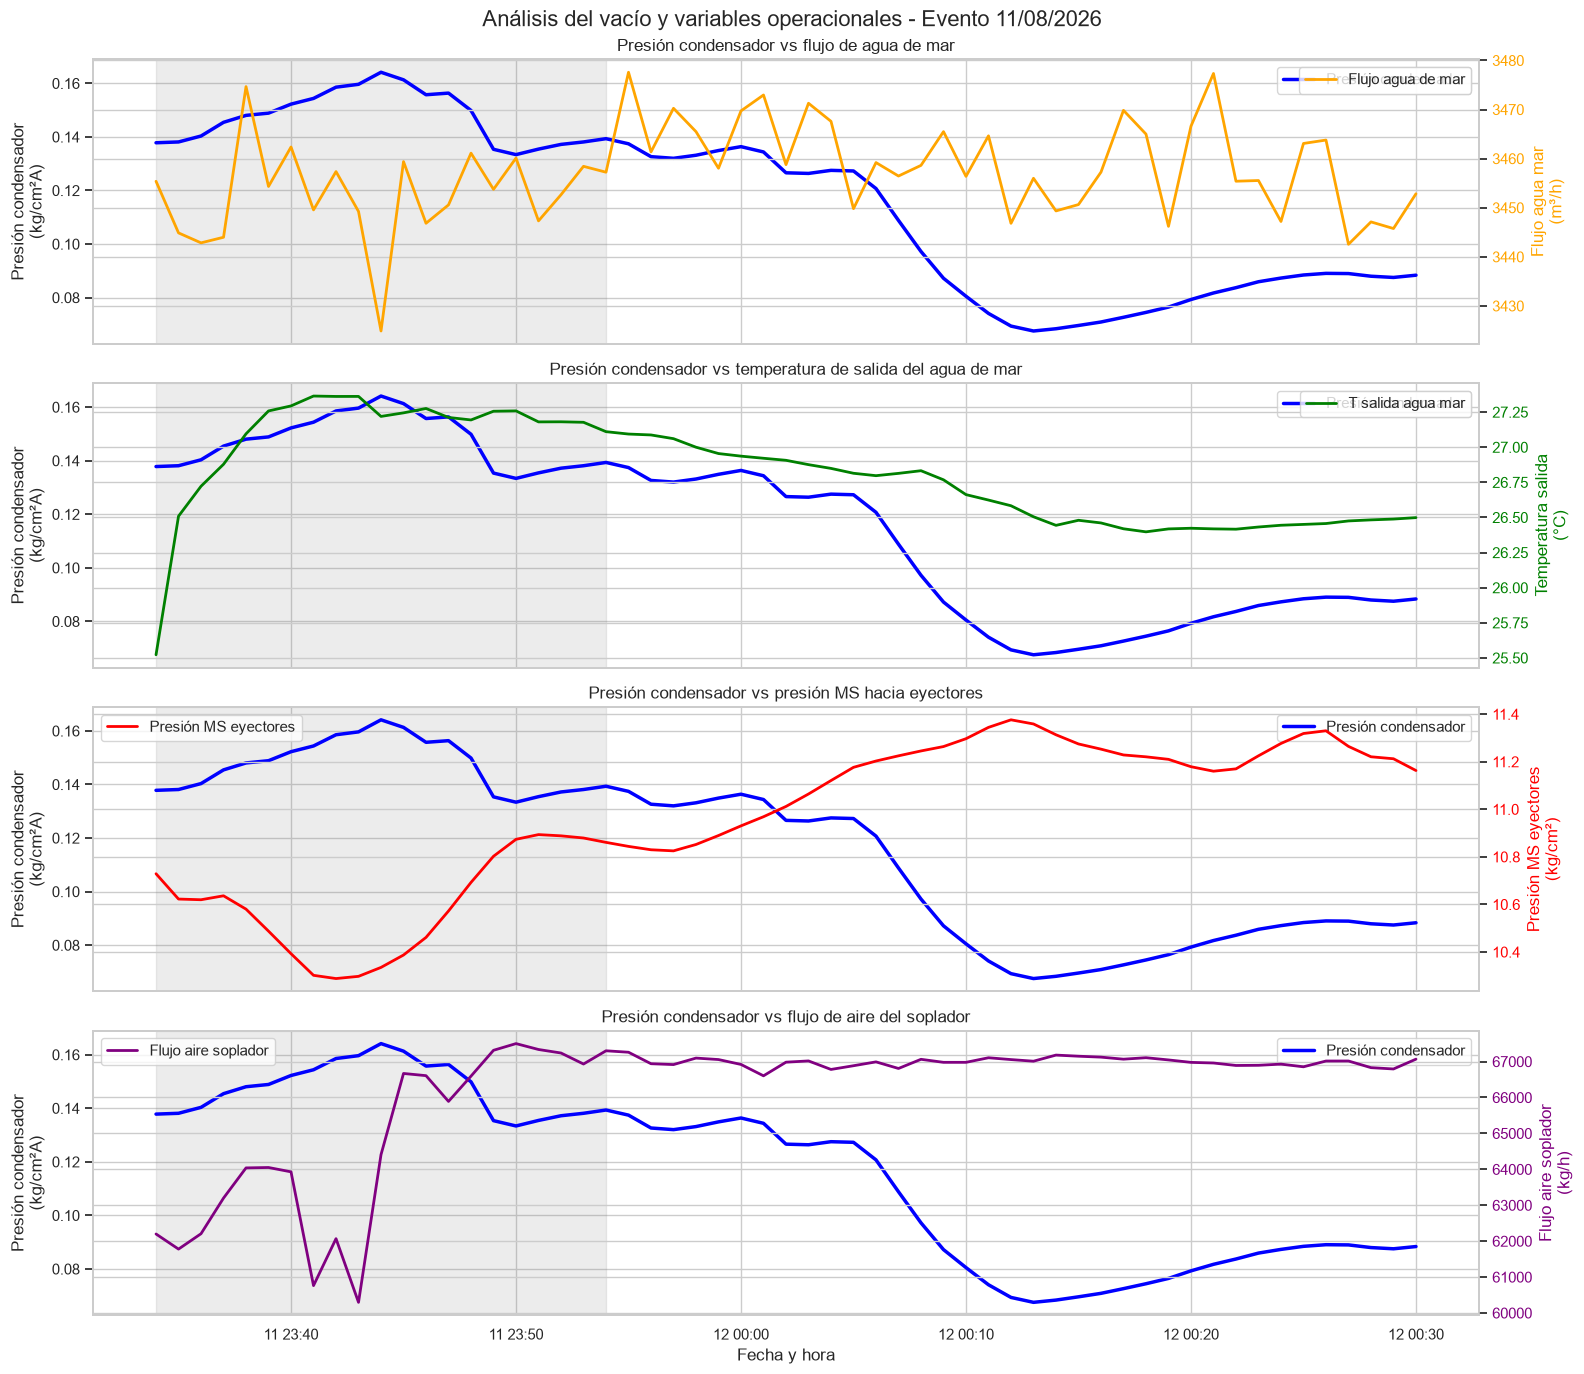

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# ESTILO SEABORN
# ============================================================

sns.set_theme(style="whitegrid")

# ============================================================
# EVENTO 11/08/2026
# ============================================================

inicio = "2026-08-11 23:20:00"
fin    = "2026-08-12 00:30:00"

evento_11 = df_operacion[
    (df_operacion["FechaHora"] >= inicio) &
    (df_operacion["FechaHora"] <= fin)
].copy()

evento_11 = evento_11.sort_values("FechaHora")

inicio_anomalia = pd.Timestamp("2026-08-11 23:34:00")
fin_anomalia    = pd.Timestamp("2026-08-11 23:54:00")


# ============================================================
# CREAR FIGURA
# ============================================================

fig, axes = plt.subplots(
    4,
    1,
    figsize=(16, 14),
    sharex=True
)


# ============================================================
# 1. PRESIÓN CONDENSADOR VS FLUJO AGUA DE MAR
# ============================================================

ax1 = axes[0]

sns.lineplot(
    data=evento_11,
    x="FechaHora",
    y="Presion_Condensador_kg_cm2A",
    ax=ax1,
    color="blue",
    linewidth=2.5,
    label="Presión condensador"
)

ax1.set_ylabel("Presión condensador\n(kg/cm²A)")
ax1.set_title("Presión condensador vs flujo de agua de mar")

ax1b = ax1.twinx()

sns.lineplot(
    data=evento_11,
    x="FechaHora",
    y="Flujo_Agua_Mar_m3_h",
    ax=ax1b,
    color="orange",
    linewidth=2,
    label="Flujo agua de mar"
)

ax1b.set_ylabel("Flujo agua mar\n(m³/h)", color="orange")
ax1b.tick_params(axis="y", labelcolor="orange")

ax1.axvspan(
    inicio_anomalia,
    fin_anomalia,
    alpha=0.15,
    color="gray"
)


# ============================================================
# 2. PRESIÓN CONDENSADOR VS T SALIDA AGUA DE MAR
# ============================================================

ax2 = axes[1]

sns.lineplot(
    data=evento_11,
    x="FechaHora",
    y="Presion_Condensador_kg_cm2A",
    ax=ax2,
    color="blue",
    linewidth=2.5,
    label="Presión condensador"
)

ax2.set_ylabel("Presión condensador\n(kg/cm²A)")
ax2.set_title(
    "Presión condensador vs temperatura de salida del agua de mar"
)

ax2b = ax2.twinx()

sns.lineplot(
    data=evento_11,
    x="FechaHora",
    y="Temp_Salida_Agua_Mar_C",
    ax=ax2b,
    color="green",
    linewidth=2,
    label="T salida agua mar"
)

ax2b.set_ylabel("Temperatura salida\n(°C)", color="green")
ax2b.tick_params(axis="y", labelcolor="green")

ax2.axvspan(
    inicio_anomalia,
    fin_anomalia,
    alpha=0.15,
    color="gray"
)


# ============================================================
# 3. PRESIÓN CONDENSADOR VS PRESIÓN MS EYECTORES
# ============================================================

ax3 = axes[2]

sns.lineplot(
    data=evento_11,
    x="FechaHora",
    y="Presion_Condensador_kg_cm2A",
    ax=ax3,
    color="blue",
    linewidth=2.5,
    label="Presión condensador"
)

ax3.set_ylabel("Presión condensador\n(kg/cm²A)")
ax3.set_title(
    "Presión condensador vs presión MS hacia eyectores"
)

ax3b = ax3.twinx()

sns.lineplot(
    data=evento_11,
    x="FechaHora",
    y="Presion_MS_Eyectores_kg_cm2",
    ax=ax3b,
    color="red",
    linewidth=2,
    label="Presión MS eyectores"
)

ax3b.set_ylabel("Presión MS eyectores\n(kg/cm²)", color="red")
ax3b.tick_params(axis="y", labelcolor="red")

ax3.axvspan(
    inicio_anomalia,
    fin_anomalia,
    alpha=0.15,
    color="gray"
)


# ============================================================
# 4. PRESIÓN CONDENSADOR VS FLUJO AIRE SOPLADOR
# ============================================================

ax4 = axes[3]

sns.lineplot(
    data=evento_11,
    x="FechaHora",
    y="Presion_Condensador_kg_cm2A",
    ax=ax4,
    color="blue",
    linewidth=2.5,
    label="Presión condensador"
)

ax4.set_ylabel("Presión condensador\n(kg/cm²A)")
ax4.set_title(
    "Presión condensador vs flujo de aire del soplador"
)

ax4b = ax4.twinx()

sns.lineplot(
    data=evento_11,
    x="FechaHora",
    y="Flujo_Aire_Soplador_kg_h",
    ax=ax4b,
    color="purple",
    linewidth=2,
    label="Flujo aire soplador"
)

ax4b.set_ylabel("Flujo aire soplador\n(kg/h)", color="purple")
ax4b.tick_params(axis="y", labelcolor="purple")

ax4.axvspan(
    inicio_anomalia,
    fin_anomalia,
    alpha=0.15,
    color="gray"
)

ax4.set_xlabel("Fecha y hora")


# ============================================================
# TÍTULO GENERAL
# ============================================================

plt.suptitle(
    "Análisis del vacío y variables operacionales - Evento 11/08/2026",
    fontsize=16
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()